In [1]:
#Connect to Database
from pymongo import MongoClient
from bson import ObjectId
client = MongoClient('mongodb://localhost:27017/')  
print('Connected to MongoDB')
db = client['nlp-based-sentiment-analysis']
markets = db['markets']
prices = db['prices']
tweets = db['tweets']
economic_indicators = db['economicindicators']
keywords = db['keywords']

Connected to MongoDB


In [2]:
#Visualize data
import pandas as pd
import matplotlib.pyplot as plt

def show_table(data, fields):
    df = pd.DataFrame(data=data)
    df = df[fields]
    df.sort_values(by=fields[0], inplace=True)
    return df

#Markets
show_table(list(markets.find({})), ["name", "_id"])

,name,_id
1,Amazon,6511914e0ef18f573bbaaef7
2,Apple,651191fe78ae8da19ab7c36c
0,Bitcoin,651190e1ecfac48ef56a09a4
3,Google,651192563a3effb2a61c3e3c
4,Microsoft,651192804ab1a96068cf401b
5,Tesla,6511928ffcd8828db8c32abc


In [3]:
#Amazon Data
show_table(list(prices.find({"market": ObjectId("6511914e0ef18f573bbaaef7")})), ["date", "close", "volume"])

,date,close,volume
0,2013-07-08T00:00:00.000Z,14.529500,60934000
1,2013-07-09T00:00:00.000Z,14.576500,55512000
2,2013-07-10T00:00:00.000Z,14.616500,36204000
3,2013-07-11T00:00:00.000Z,14.983000,80146000
4,2013-07-12T00:00:00.000Z,15.377500,90786000
...,...,...,...
2512,2023-06-29T00:00:00.000Z,127.900002,40761000
2513,2023-06-30T00:00:00.000Z,130.360001,54310500
2514,2023-07-03T00:00:00.000Z,130.220001,28264800
2515,2023-07-05T00:00:00.000Z,130.380005,35895400


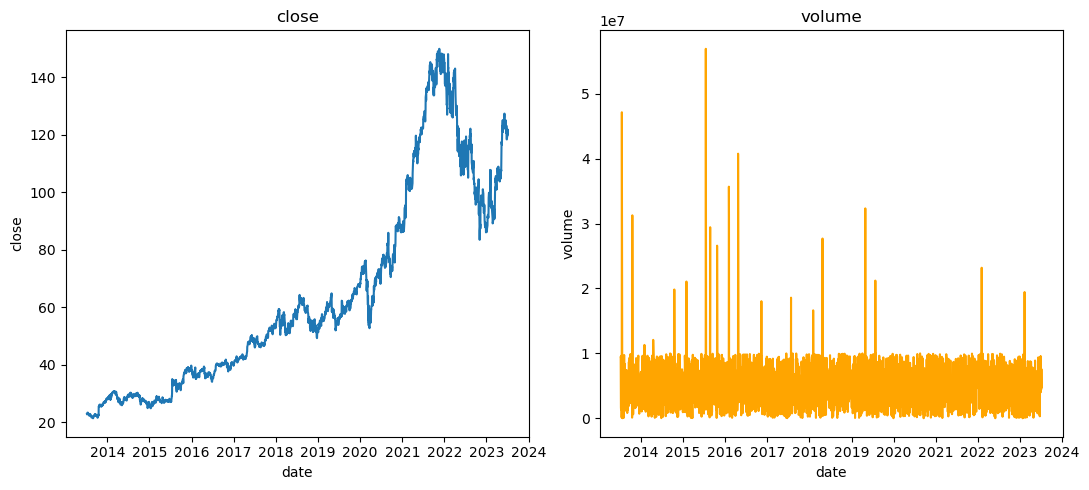

In [4]:
def print_plots(dataframe_a, dataframe_b, field_a, field_b, custom_a_name='', custom_b_name=''):
    dataframe_a['date'] = pd.to_datetime(dataframe_a['date'])
    dataframe_b['date'] = pd.to_datetime(dataframe_b['date'])
    plt.figure(figsize=(11,5))
    plt.subplot(1,2,1)
    plt.plot(dataframe_a['date'], dataframe_a[field_a])
    plt.title(custom_a_name if custom_a_name else field_a)
    plt.xlabel("date")
    plt.ylabel(custom_a_name if custom_a_name else field_a)
    plt.subplot(1,2,2)
    plt.plot(dataframe_b['date'], dataframe_b[field_b], color="orange")
    plt.title(custom_b_name if custom_b_name else field_b)
    plt.xlabel("date")
    plt.ylabel(custom_b_name if custom_b_name else field_b)
    plt.tight_layout()
    plt.show()

google_df = pd.DataFrame(data=list(prices.find({"market": ObjectId("651192563a3effb2a61c3e3c")})))
#Print Google Market Chart
print_plots(pd.DataFrame(data=google_df), pd.DataFrame(data=google_df), 'close', 'volume')

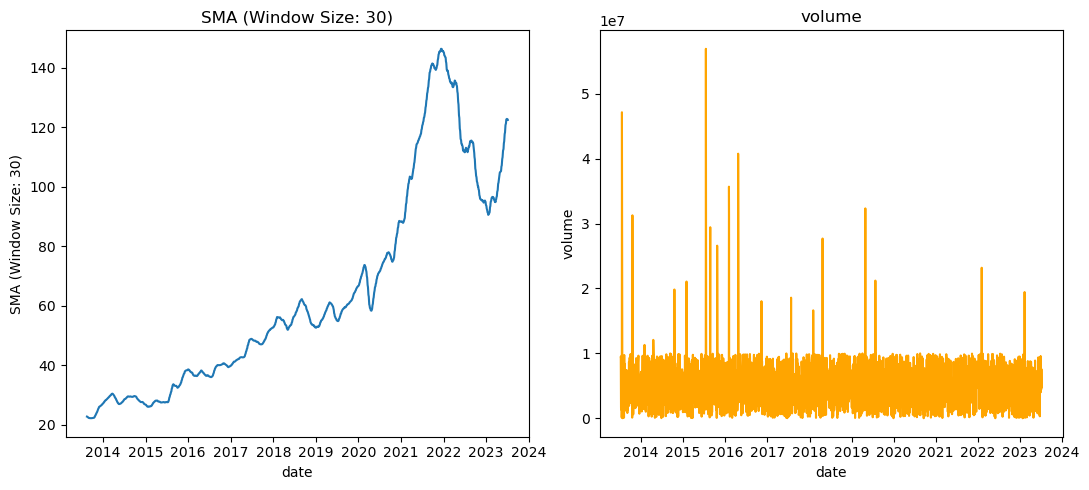

In [5]:
def sma(data, window_size):
    return data.rolling(window=window_size).mean()

#Apply Simple Moving Average to Close Value
google_df["close"] = sma(google_df["close"], window_size=30)
print_plots(pd.DataFrame(data=google_df), pd.DataFrame(data=google_df), 'close', 'volume', custom_a_name="SMA (Window Size: 30)")

In [6]:
show_table(list(set([doc['type'] for doc in economic_indicators.find()])), [0])

,0
0,CPI
4,DurableGoodsOrders
5,FederalFundsRate
8,Inflation
7,NonfarmPayroll
2,RealGDP
1,RealGDPPerCapita
3,RetailSales
6,TreasuryYield
9,UnemploymentRate


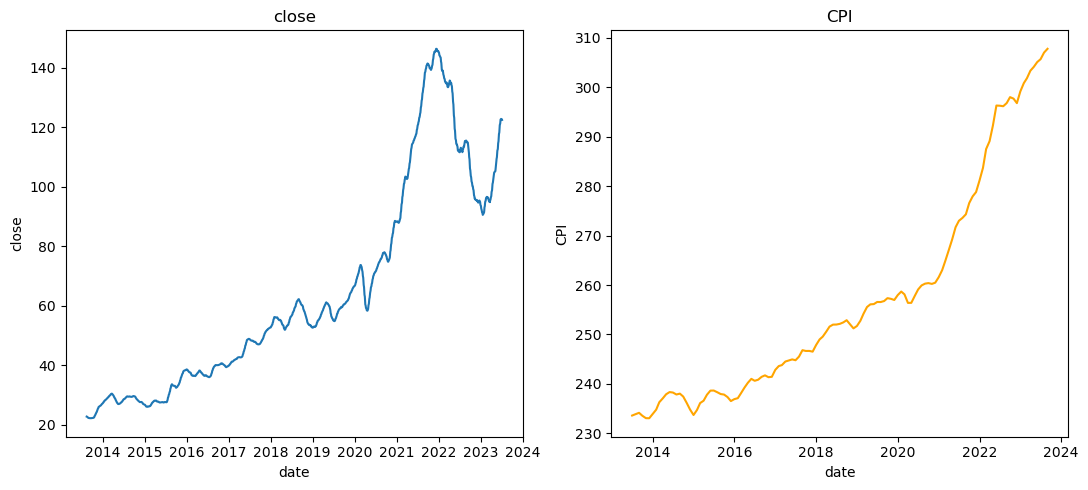

In [7]:
from datetime import datetime
#Show SMA Value next to Technical indicators:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({ "type": "CPI", "date": { "$gte": "2013-07-01" }}))),
    'close', 
    'value', 
    custom_b_name="CPI"
)

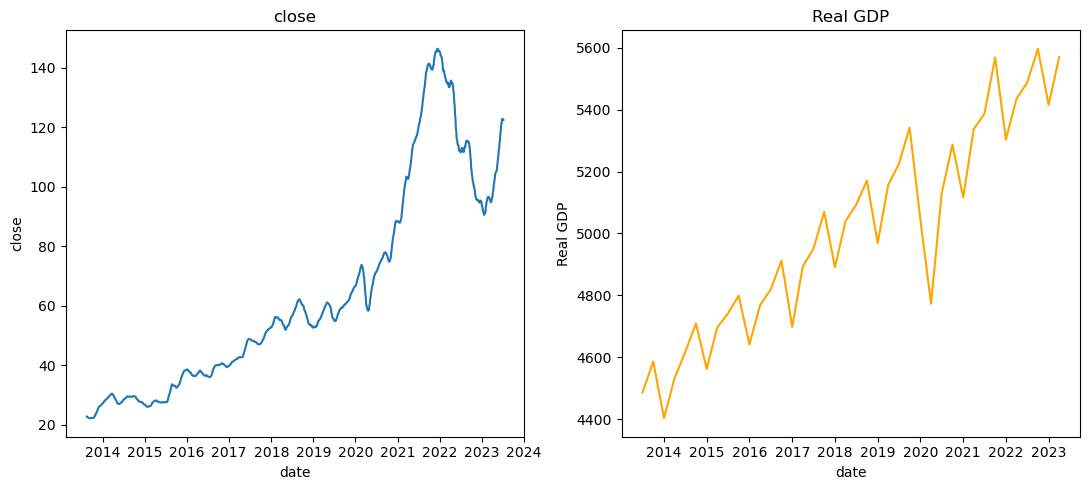

In [8]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "RealGDP", "date": { "$gte": "2013-07-01" }  }))),
    'close',
    'value',
    custom_b_name="Real GDP"
)

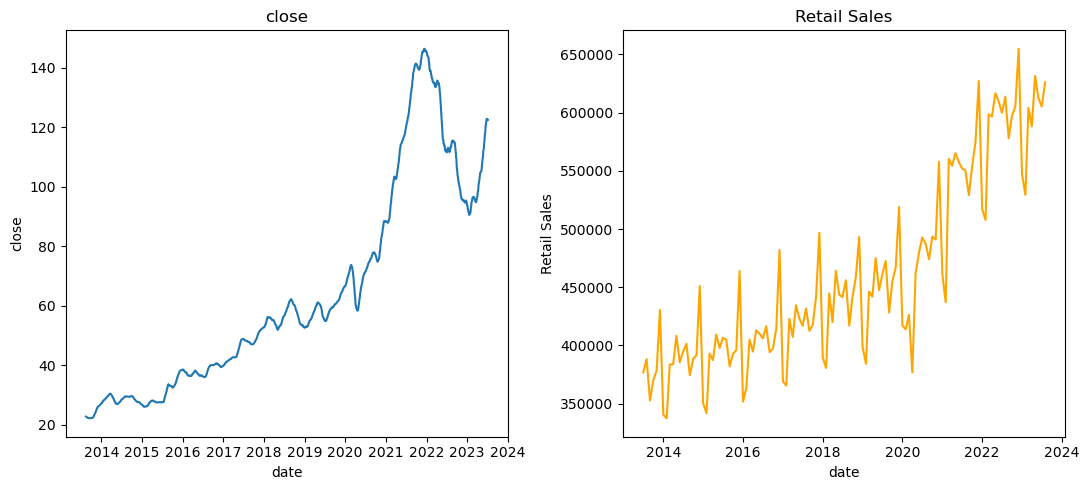

In [9]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "RetailSales", "date": { "$gte": "2013-07-01" } }))), 
    'close',
    'value',
    custom_b_name="Retail Sales"
)

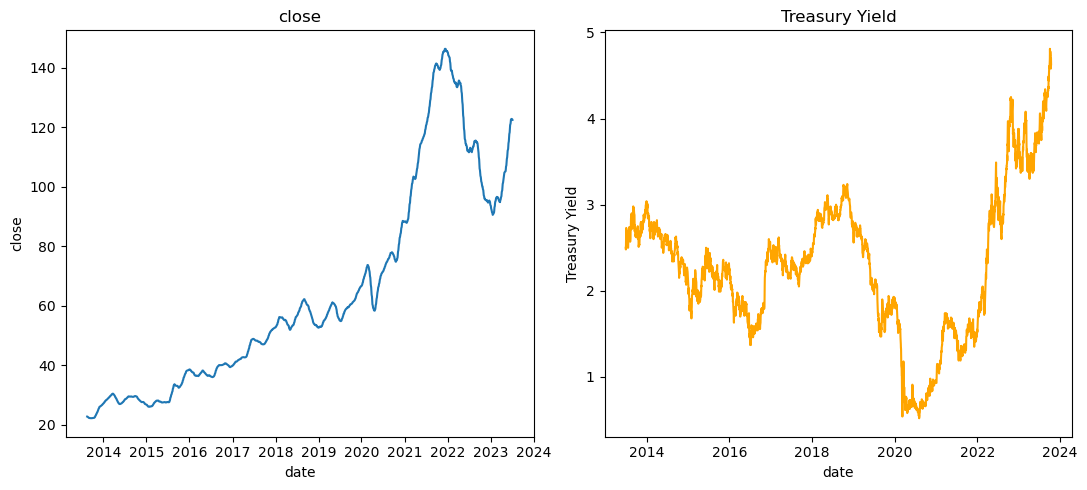

In [10]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "TreasuryYield", "date": { "$gte": "2013-07-01" } }))),
    'close',
    'value',
    custom_b_name="Treasury Yield"
)

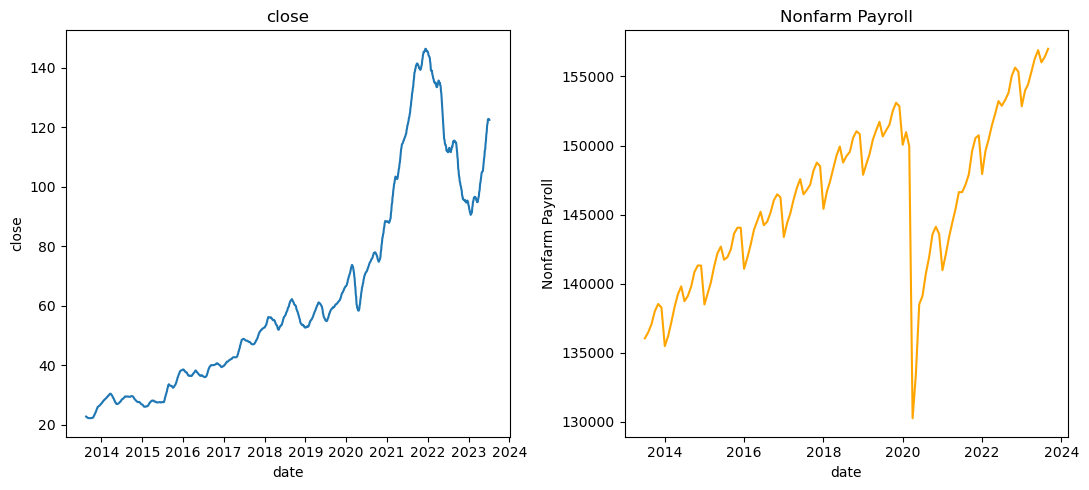

In [11]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "NonfarmPayroll", "date": { "$gte": "2013-07-01" } }))),
    'close',
    'value',
    custom_b_name="Nonfarm Payroll"
)

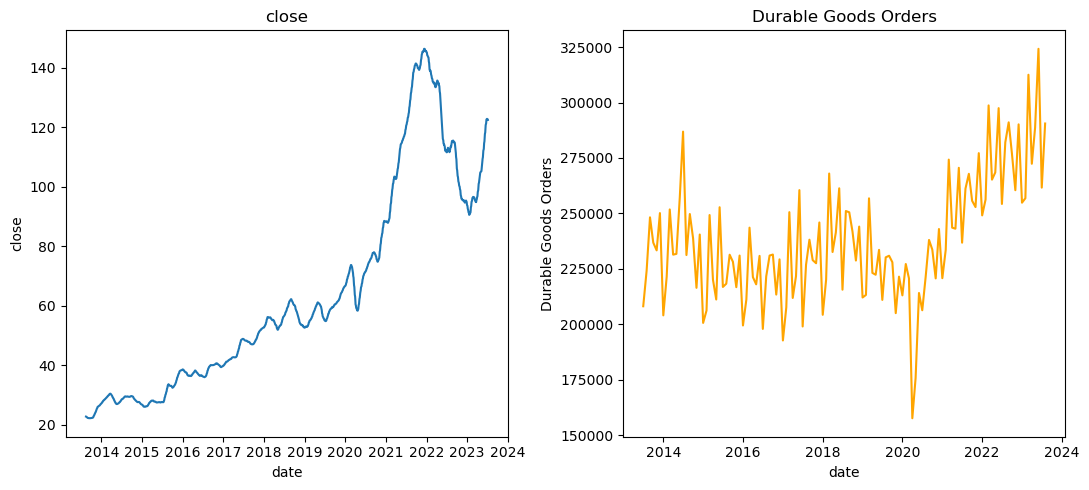

In [12]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "DurableGoodsOrders", "date": { "$gte": "2013-07-01" } }))),
    'close',
    'value',
    custom_b_name="Durable Goods Orders"
)

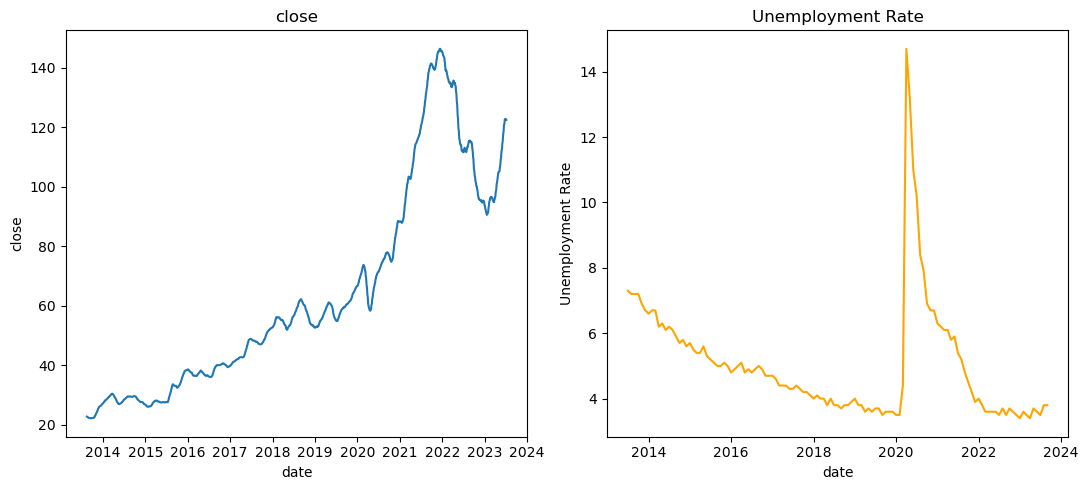

In [13]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "UnemploymentRate", "date": { "$gte": "2013-07-01" } }))),
    'close',
    'value',
    custom_b_name="Unemployment Rate"
)

In [14]:
show_table(pd.DataFrame(data=list(keywords.find())), ["name", "_id"])

,name,_id
1,Bitcoin,65118dfb8cc92b1a20969084
0,Investing,65108e38c1df798eb02becb3


In [15]:
tweet_list = tweets.find({"keyword": ObjectId("65108e38c1df798eb02becb3"), "date": { "$lte": "2021-01-01" }})

In [16]:
show_table(pd.DataFrame(data=list(tweet_list)), ["date", "content"])

,date,content
491,2015-01-01T21:35:12.000Z,Difference between Following and Capturing Tre...
490,2015-01-01T21:35:13.000Z,Machine Learning vs Systematic Trading http://...
489,2015-01-01T21:35:19.000Z,How a Manager Knew He Wanted to Be a Trader ht...
488,2015-01-01T21:35:44.000Z,Questions Missed During Due Diligence http://t...
487,2015-01-01T21:36:16.000Z,Insights From Seasoned Trend Follower http://t...
...,...,...
1057895,2020-12-31T23:56:11.000Z,$DCO in Downtrend: RSI indicator exits overbou...
1057894,2020-12-31T23:56:27.000Z,#CleanEnergy: In Name And In Deed In A Time Of...
1057893,2020-12-31T23:57:05.000Z,Check out my new tiktok video \n\nhttps://t.co...
1057892,2020-12-31T23:59:15.000Z,$JOUT's in Uptrend: Moving Average Convergence...


In [17]:
import re
def apply_transformations(transformations, text):
    if "REMOVE_USERNAMES" in transformations:
        remove_usernames_pattern = r'@\S+'
        text = re.sub(remove_usernames_pattern, "", text)
    if "REMOVE_URLS" in transformations:
        remove_urls_pattern = r'http\S+'
        text = re.sub(remove_urls_pattern, "", text)
    if "REMOVE_PUNCTUATION_MARKS" in transformations:
        remove_pun_pattern_1 = r"(?<!\d)\.(?!\d)|[^\w\s.']"
        remove_pun_pattern_2 = r"'"
        remove_pun_pattern_3 = r"\s\s+"
        sub1 = re.sub(remove_pun_pattern_1, " ", text)
        sub2 = re.sub(remove_pun_pattern_2, "", sub1)
        text = re.sub(remove_pun_pattern_3, " ", sub2)
    if "TEXT_TO_LOWER" in transformations:
        text = text.lower()
    if "REMOVE_SHORT_WORDS" in transformations:
        remove_short_pattern = r'\b\w{1,2}\b'
        text = re.sub(remove_short_pattern, '', text)
    return text

In [18]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
analyzer = SentimentIntensityAnalyzer()

def sentiment_analyze(text):
    return analyzer.polarity_scores(text)

sentiment_analyze("I love Python!")

[nltk_data] Error loading vader_lexicon: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


{'neg': 0.0, 'neu': 0.182, 'pos': 0.818, 'compound': 0.6696}

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
nltk.download('punkt')

def text_vectorizer(text):
    tokenized = nltk.tokenize.word_tokenize(text)
    vectorizer = CountVectorizer()
    return vectorizer.fit_transform(tokenized).toarray()

text = "I would really like to tokenize and vectorize this sentence!" 
text_vectorizer(text)

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int64)

In [20]:
investing_tweet_list = tweets.find({"keyword": ObjectId("65108e38c1df798eb02becb3"), "date": { "$lte": "2021-01-01" }})
transform_types = ["REMOVE_USERNAMES", "REMOVE_URLS", "REMOVE_PUNCTUATION_MARKS", "TEXT_TO_LOWER", "REMOVE_SHORT_WORDS"]
transformed_tweet_list = [{
    "date": obj["date"],
    "content": 
        apply_transformations(transform_types, obj["content"]),
    **sentiment_analyze(apply_transformations(transform_types, obj["content"]))
} for obj in investing_tweet_list]


In [21]:
show_table(pd.DataFrame(data=list(transformed_tweet_list)), ["date", "content", "pos", "neg", "neu", "compound"])

,date,content,pos,neg,neu,compound
491,2015-01-01T21:35:12.000Z,difference between following and capturing tre...,0.000,0.000,1.000,0.0000
490,2015-01-01T21:35:13.000Z,machine learning systematic trading futures t...,0.000,0.000,1.000,0.0000
489,2015-01-01T21:35:19.000Z,how manager knew wanted trader stocks tra...,0.000,0.000,1.000,0.0000
488,2015-01-01T21:35:44.000Z,questions missed during due diligence profit t...,0.180,0.137,0.683,0.1779
487,2015-01-01T21:36:16.000Z,insights from seasoned trend follower stocks t...,0.000,0.000,1.000,0.0000
...,...,...,...,...,...,...
1057895,2020-12-31T23:56:11.000Z,dco downtrend rsi indicator exits overbought...,0.000,0.000,1.000,0.0000
1057894,2020-12-31T23:56:27.000Z,cleanenergy name and deed time need clne...,0.000,0.000,1.000,0.0000
1057893,2020-12-31T23:57:05.000Z,check out new tiktok video stocks robinhood i...,0.000,0.000,1.000,0.0000
1057892,2020-12-31T23:59:15.000Z,jouts uptrend moving average convergence div...,0.118,0.000,0.882,0.5574


In [22]:
def merge_and_accumulate(data):
    daily_data = {}
    for entry in data:
        datetime_object = datetime.strptime(entry["date"][:-1], '%Y-%m-%dT%H:%M:%S.%f')
        date_obj = datetime_object.strftime('%Y-%m-%d')
        if date_obj in daily_data:
            daily_data[date_obj]["pos"].append(entry["pos"])
            daily_data[date_obj]["neg"].append(entry["neg"])
            daily_data[date_obj]["neu"].append(entry["neu"])
            daily_data[date_obj]["compound"].append(entry["compound"])
        else:
            daily_data[date_obj] = {
                "pos": [entry["pos"]],
                "neg": [entry["neg"]],
                "neu": [entry["neu"]],
                "compound": [entry["compound"]]
            }
    mapped_array = []
    for date, info in daily_data.items():
        mapped_array.append({
            "date": date,
            "pos_avg": sum(info["pos"]) / len(info["pos"]),
            "neg_avg": sum(info["neg"]) / len(info["neg"]),
            "neu_avg": sum(info["neu"]) / len(info["neu"]),
            "compound_avg": sum(info["compound"]) / len(info["compound"])
        })
    return mapped_array

In [23]:
average_sentiments = list(merge_and_accumulate(transformed_tweet_list))

In [24]:
show_table(pd.DataFrame(data=average_sentiments), ["date", "pos_avg", "neg_avg", "neu_avg", "compound_avg"])

,date,pos_avg,neg_avg,neu_avg,compound_avg
0,2015-01-01,0.190041,0.061222,0.748730,0.261172
1,2015-01-02,0.198655,0.058135,0.743191,0.277338
2,2015-01-03,0.199753,0.061235,0.738984,0.281095
3,2015-01-04,0.204832,0.058584,0.736552,0.289359
4,2015-01-05,0.179689,0.051098,0.769199,0.257767
...,...,...,...,...,...
2187,2020-12-27,0.119077,0.030721,0.850206,0.252568
2188,2020-12-28,0.121486,0.026193,0.852328,0.279167
2189,2020-12-29,0.114245,0.030363,0.855380,0.230806
2190,2020-12-30,0.117647,0.030049,0.852295,0.251296


In [25]:
google_df = pd.DataFrame(data=google_df)
average_sentiments_df = pd.DataFrame(data=average_sentiments)

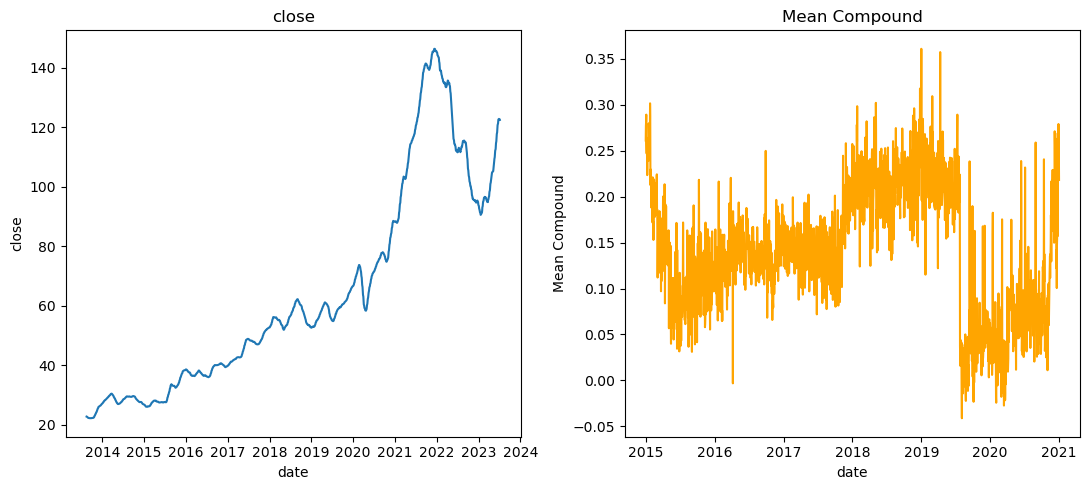

In [26]:
print_plots(
    google_df,
    average_sentiments_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound"
)

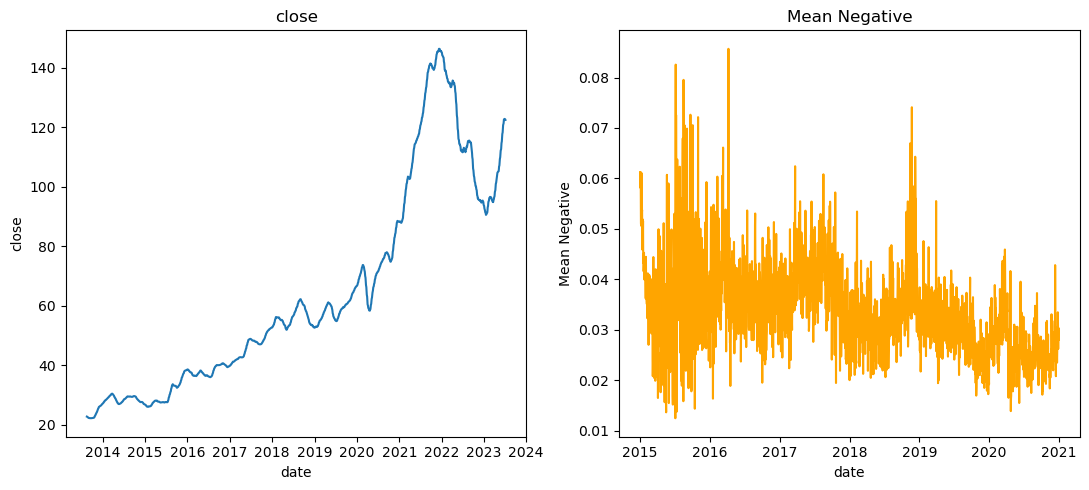

In [27]:
print_plots(
    google_df,
    average_sentiments_df,
    'close',
    'neg_avg',
    custom_b_name="Mean Negative"
)

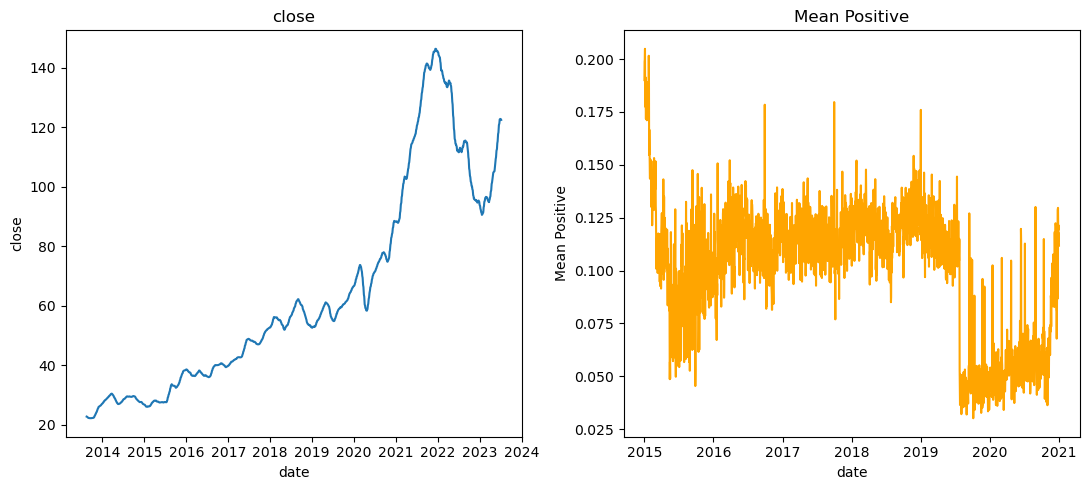

In [28]:
print_plots(
    google_df,
    average_sentiments_df,
    'close',
    'pos_avg',
    custom_b_name="Mean Positive"
)

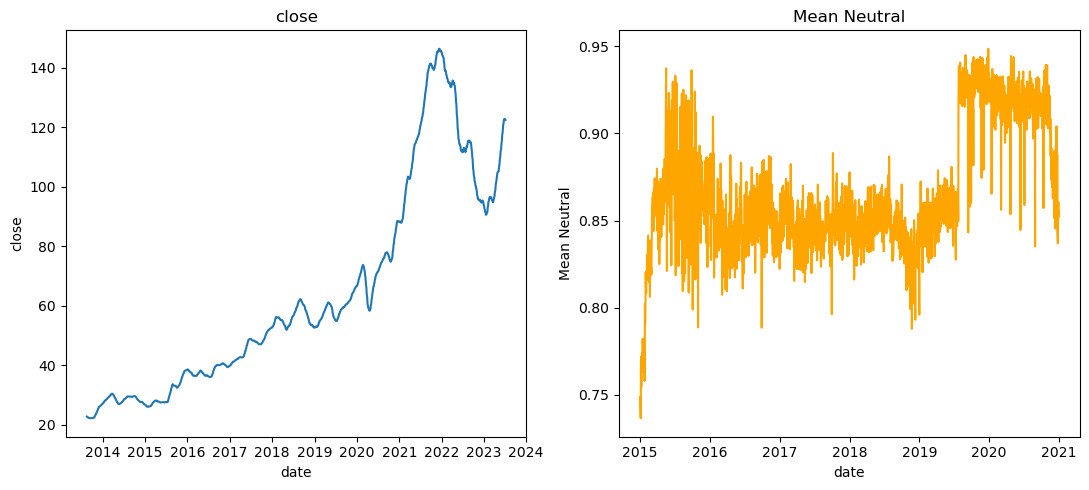

In [29]:
print_plots(
    google_df,
    average_sentiments_df,
    'close',
    'neu_avg',
    custom_b_name="Mean Neutral"
)

In [30]:
import numpy as np

def apply_min_max(data):
    return (data - np.min(data, axis=0)) / (np.max(data, axis=0) - np.min(data, axis=0))
def apply_standarization(data):
    return (data - np.mean(data)) / np.std(data)

In [31]:
average_sentiments_min_max = average_sentiments_df
average_sentiments_min_max["compound_avg"] = apply_min_max(average_sentiments_min_max["compound_avg"])

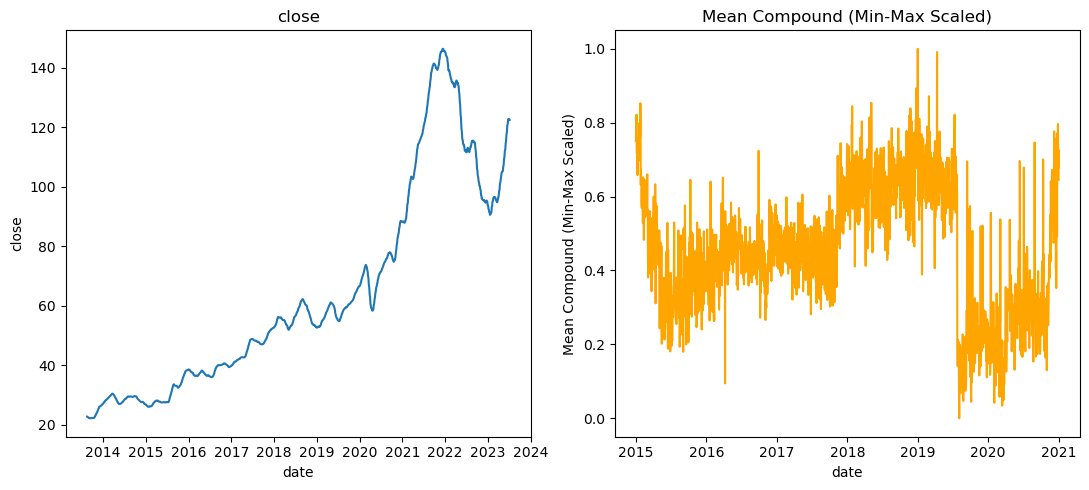

In [32]:
print_plots(
    google_df,
    average_sentiments_min_max,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Min-Max Scaled)"
)

In [33]:
average_sentiments_std = average_sentiments_df
average_sentiments_std["compound_avg"] = apply_standarization(average_sentiments_std["compound_avg"])

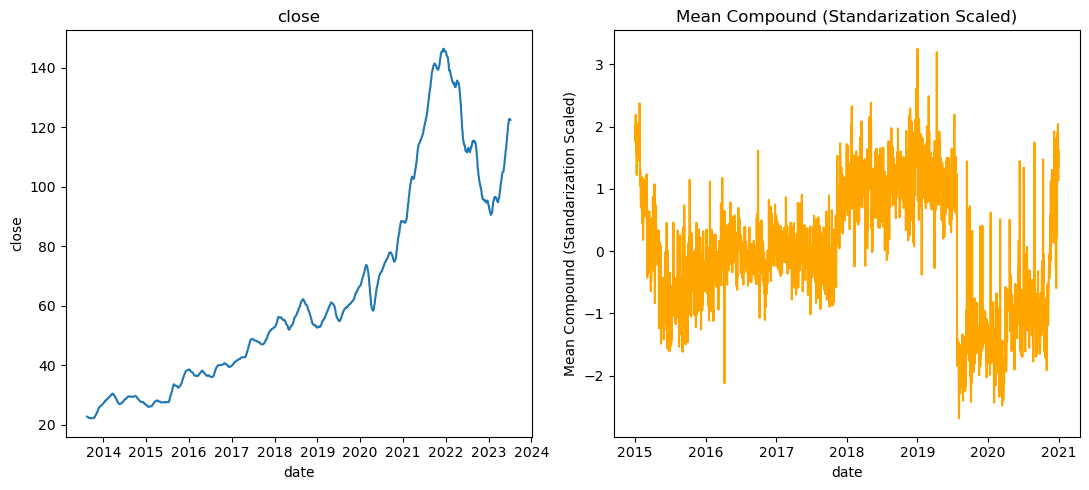

In [34]:
print_plots(
    google_df,
    average_sentiments_std,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Standarization Scaled)"
)

In [35]:
average_sentiments_minmax_sma = average_sentiments_df
average_sentiments_minmax_sma["compound_avg"] = sma(apply_min_max(average_sentiments_minmax_sma["compound_avg"]), 30)

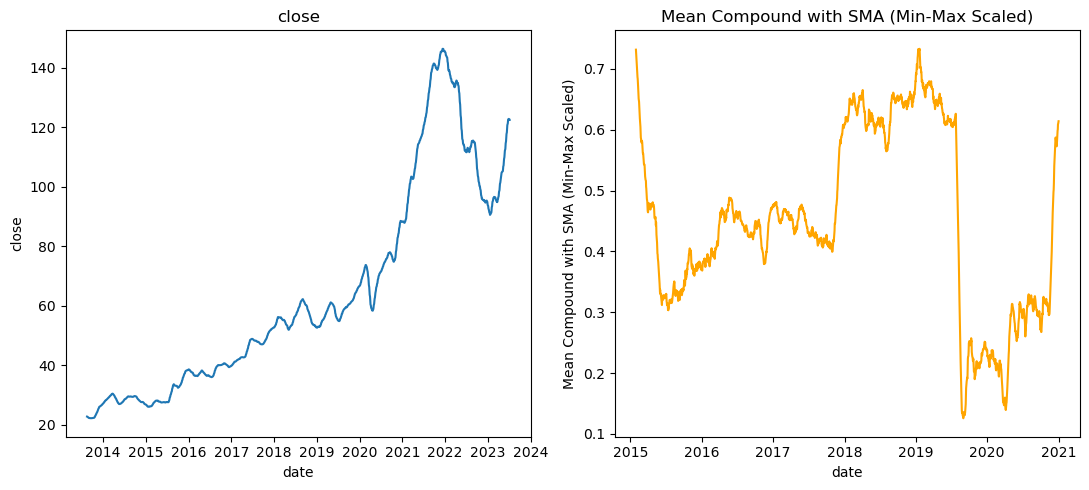

In [36]:
print_plots(
    google_df,
    average_sentiments_minmax_sma,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound with SMA (Min-Max Scaled)"
)

In [37]:
average_sentiments_std_sma = average_sentiments_df
average_sentiments_std_sma["compound_avg"] = sma(apply_standarization(average_sentiments_std_sma["compound_avg"]), 30)

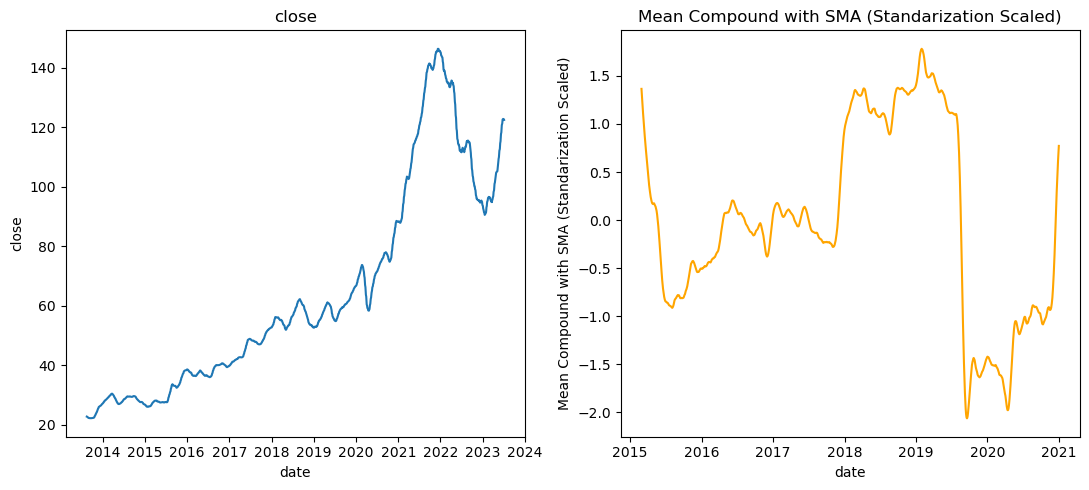

In [38]:
print_plots(
    google_df,
    average_sentiments_std_sma,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound with SMA (Standarization Scaled)"
)

In [39]:
all_sentiments = pd.DataFrame(data=transformed_tweet_list)

In [40]:
all_sentiments_min_max = all_sentiments
all_sentiments_min_max["compound"] = apply_min_max(all_sentiments_min_max["compound"])
all_sentiments_min_max_dict = all_sentiments_min_max.to_dict(orient='records')
all_sentiments_min_max_dict_average = list(merge_and_accumulate(all_sentiments_min_max_dict))
all_sentiments_min_max_dict_average_df = pd.DataFrame(data=all_sentiments_min_max_dict_average)

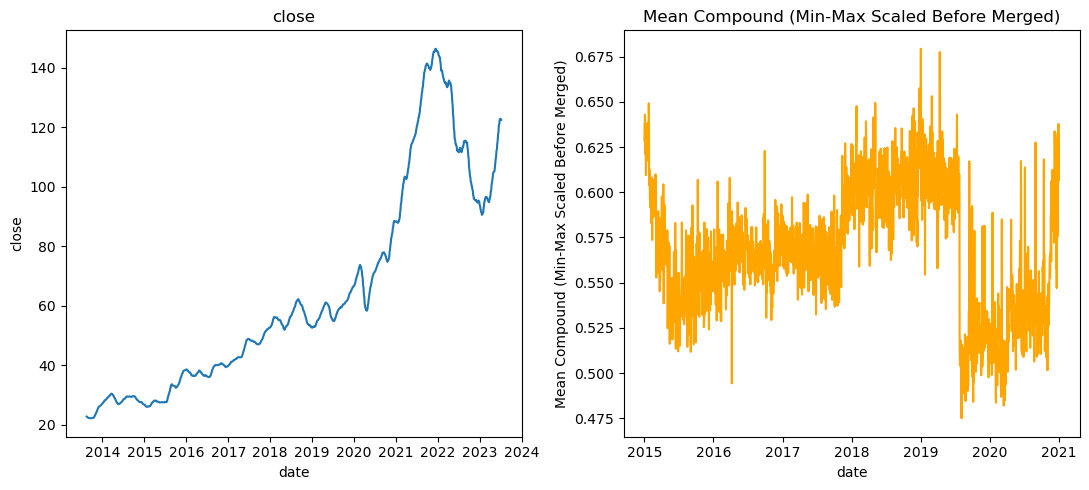

In [41]:
print_plots(
    google_df,
    all_sentiments_min_max_dict_average_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Min-Max Scaled Before Merged)"
)

In [42]:
all_sentiments_std = all_sentiments
all_sentiments_std["compound"] = apply_standarization(all_sentiments_std["compound"])
all_sentiments_std_dict = all_sentiments_std.to_dict(orient='records')
all_sentiments_std_dict_average = list(merge_and_accumulate(all_sentiments_std_dict))
all_sentiments_std_dict_average_df = pd.DataFrame(data=all_sentiments_std_dict_average)

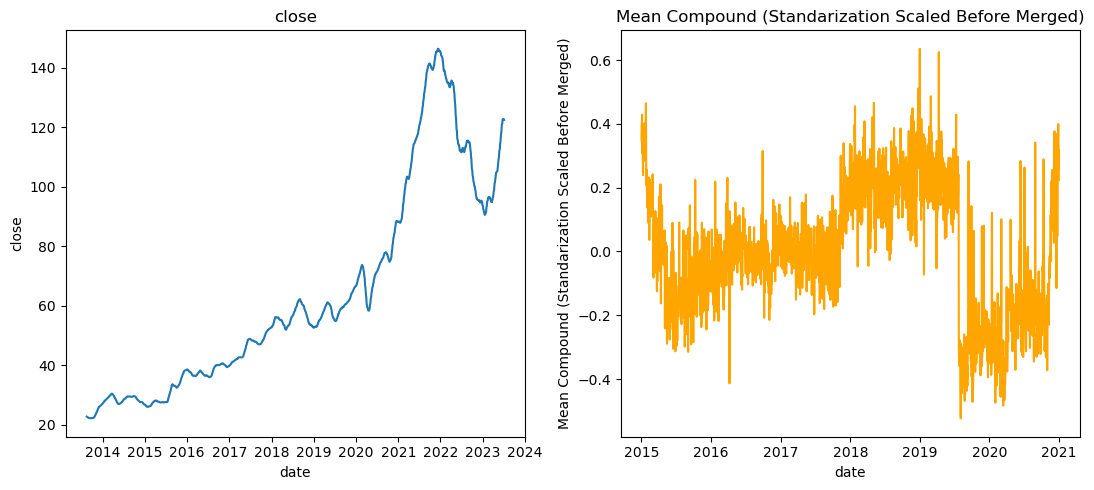

In [43]:
print_plots(
    google_df,
    all_sentiments_std_dict_average_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Standarization Scaled Before Merged)"
)

In [44]:
all_sentiments_min_max_dict_average_sma_df = pd.DataFrame(all_sentiments_min_max_dict_average)
all_sentiments_min_max_dict_average_sma_df["compound_avg"] = sma(all_sentiments_min_max_dict_average_sma_df["compound_avg"], 30)

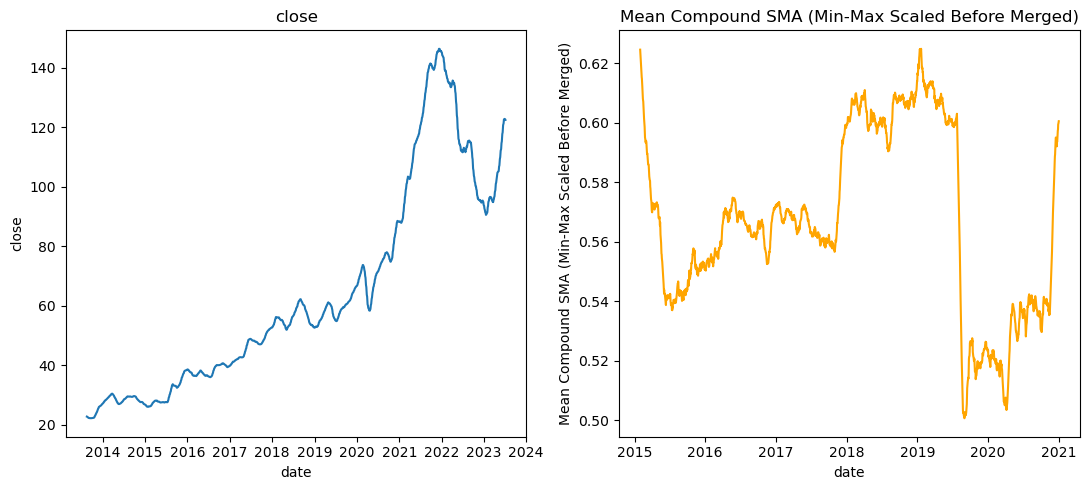

In [45]:
print_plots(
    google_df,
    all_sentiments_min_max_dict_average_sma_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound SMA (Min-Max Scaled Before Merged)"
)

In [46]:
all_sentiments_std_dict_average_sma_df = pd.DataFrame(all_sentiments_std_dict_average)
all_sentiments_std_dict_average_sma_df["compound_avg"] = sma(all_sentiments_std_dict_average_sma_df["compound_avg"], 30)

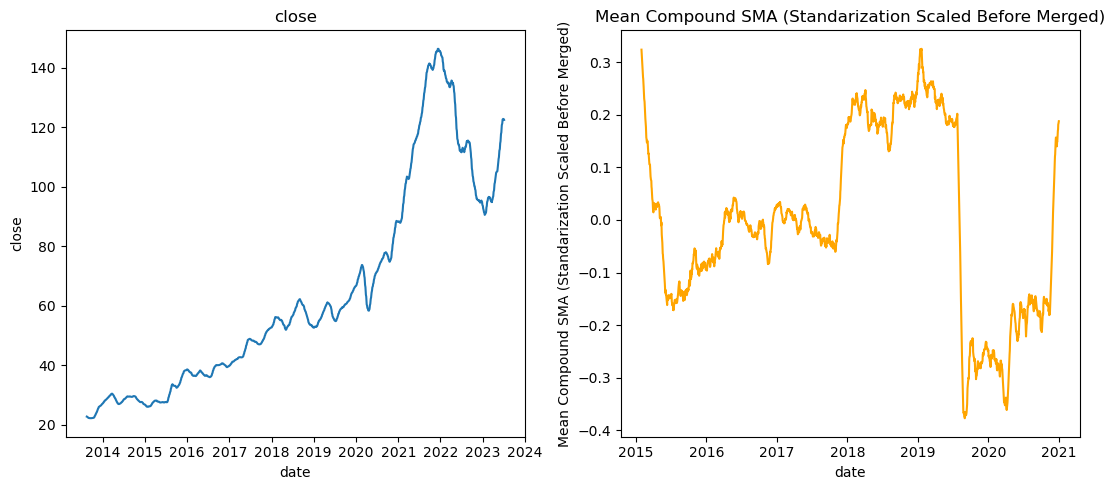

In [47]:
print_plots(
    google_df,
    all_sentiments_std_dict_average_sma_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound SMA (Standarization Scaled Before Merged)"
)

In [48]:
#Compare Scale Before And After Merge

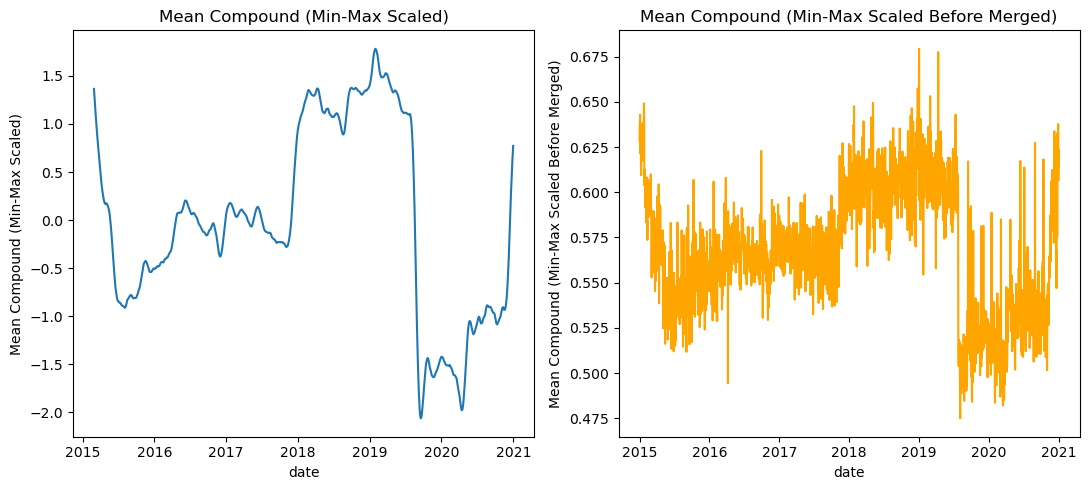

In [49]:
print_plots(
    average_sentiments_min_max,
    all_sentiments_min_max_dict_average_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound (Min-Max Scaled)",
    custom_b_name="Mean Compound (Min-Max Scaled Before Merged)"
)

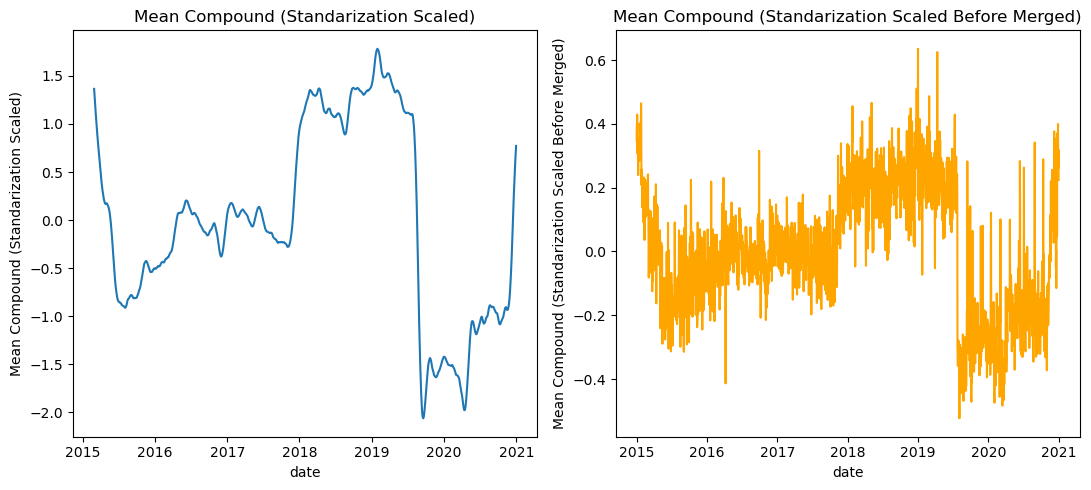

In [50]:
print_plots(
    average_sentiments_std,
    all_sentiments_std_dict_average_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound (Standarization Scaled)",
    custom_b_name="Mean Compound (Standarization Scaled Before Merged)"
)

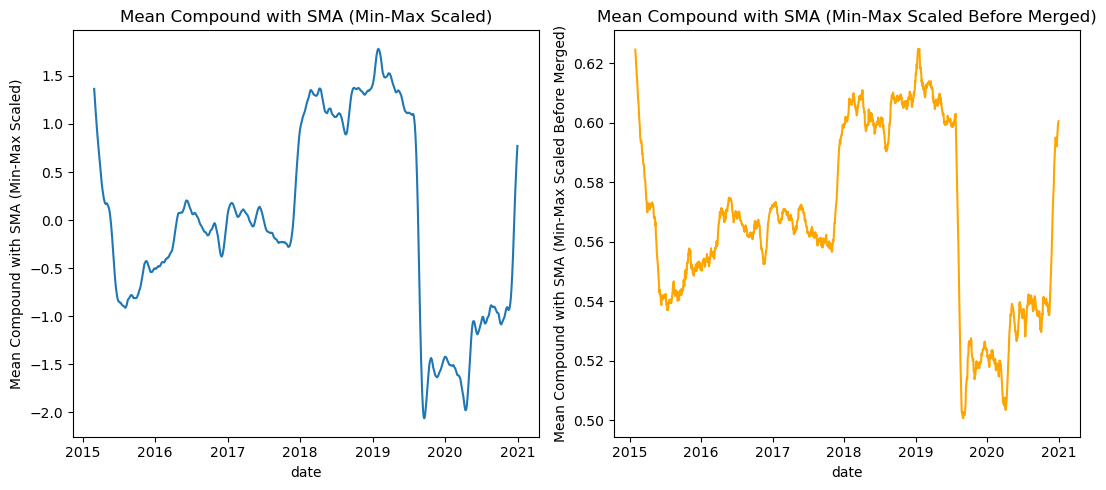

In [51]:
print_plots(
    average_sentiments_minmax_sma,
    all_sentiments_min_max_dict_average_sma_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound with SMA (Min-Max Scaled)",
    custom_b_name="Mean Compound with SMA (Min-Max Scaled Before Merged)"
)

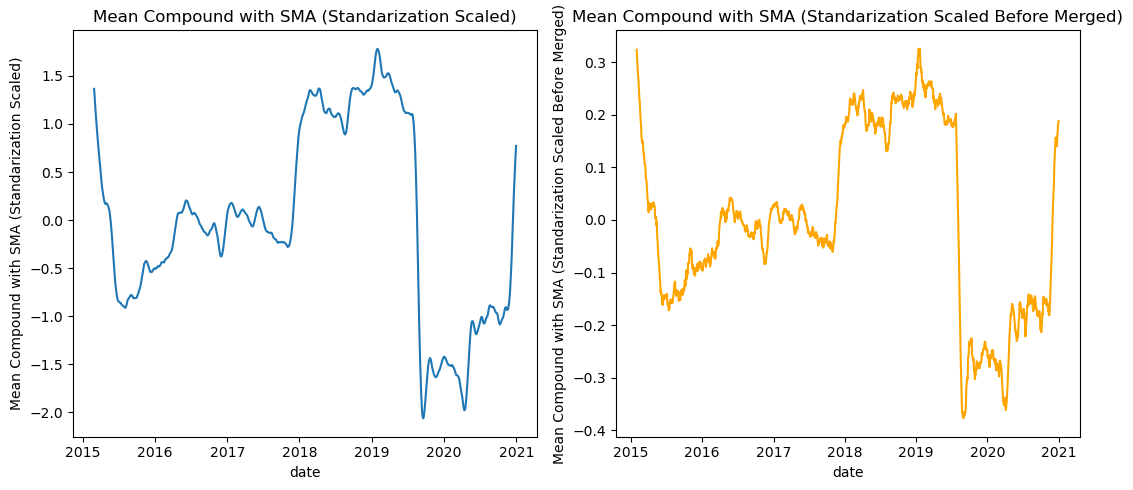

In [52]:
print_plots(
    average_sentiments_std_sma,
    all_sentiments_std_dict_average_sma_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound with SMA (Standarization Scaled)",
    custom_b_name="Mean Compound with SMA (Standarization Scaled Before Merged)"
)

In [53]:
bitcoin_tweet_list = tweets.find({"keyword": ObjectId("65118dfb8cc92b1a20969084")})
transform_types = ["REMOVE_USERNAMES", "REMOVE_URLS", "REMOVE_PUNCTUATION_MARKS", "TEXT_TO_LOWER", "REMOVE_SHORT_WORDS"]
transformed_bitcoin_tweet_list = [{
    "date": obj["date"],
    "content": 
        apply_transformations(transform_types, obj["content"]),
    **sentiment_analyze(apply_transformations(transform_types, obj["content"]))
} for obj in bitcoin_tweet_list]
bitcoin_average_sentiments = list(merge_and_accumulate(transformed_bitcoin_tweet_list))
bitcoin_average_sentiments_df = pd.DataFrame(data=bitcoin_average_sentiments)
show_table(bitcoin_average_sentiments_df, ["date", "pos_avg", "neg_avg", "neu_avg", "compound_avg"])

,date,pos_avg,neg_avg,neu_avg,compound_avg
0,2015-01-01,0.135542,0.042750,0.821708,0.136219
1,2015-01-02,0.122563,0.034000,0.843437,0.135810
2,2015-01-03,0.161378,0.071911,0.766667,0.181362
3,2015-01-04,0.104744,0.072116,0.776698,0.042423
4,2015-01-05,0.119860,0.072000,0.808160,0.146510
...,...,...,...,...,...
2916,2022-12-27,0.106690,0.076619,0.816738,0.006883
2917,2022-12-28,0.127054,0.037189,0.835811,0.144024
2918,2022-12-29,0.159487,0.061872,0.778615,0.172726
2919,2022-12-30,0.122244,0.080537,0.797171,0.058293


In [54]:
bitcoin_df = pd.DataFrame(data=list(prices.find({"market": ObjectId("651190e1ecfac48ef56a09a4"), "date": { "$gte": "2015-01-01" }})))

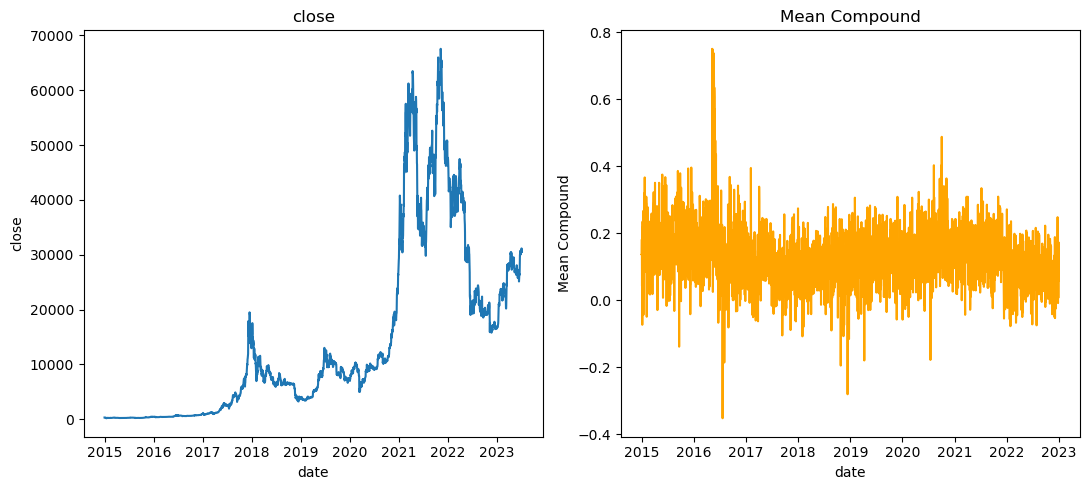

In [55]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound"
)

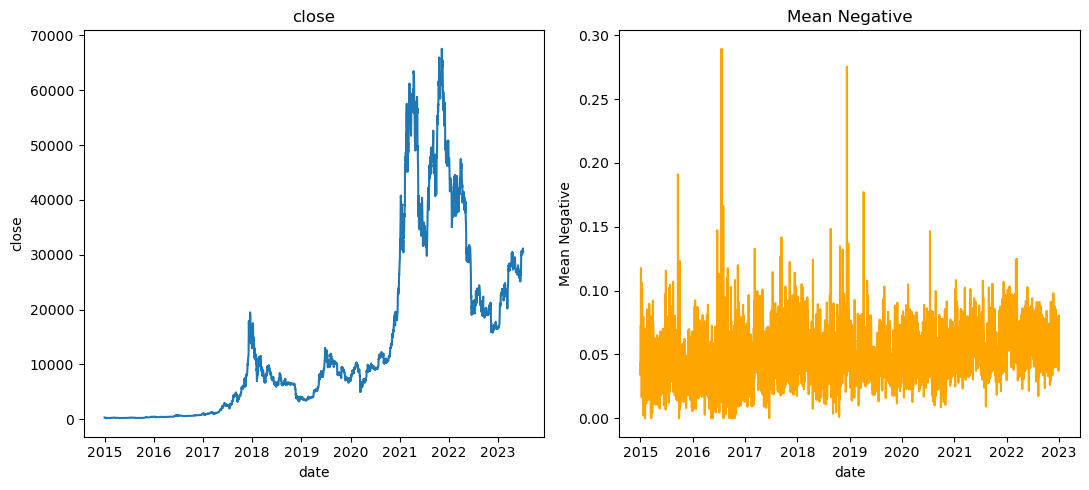

In [56]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_df,
    'close',
    'neg_avg',
    custom_b_name="Mean Negative"
)

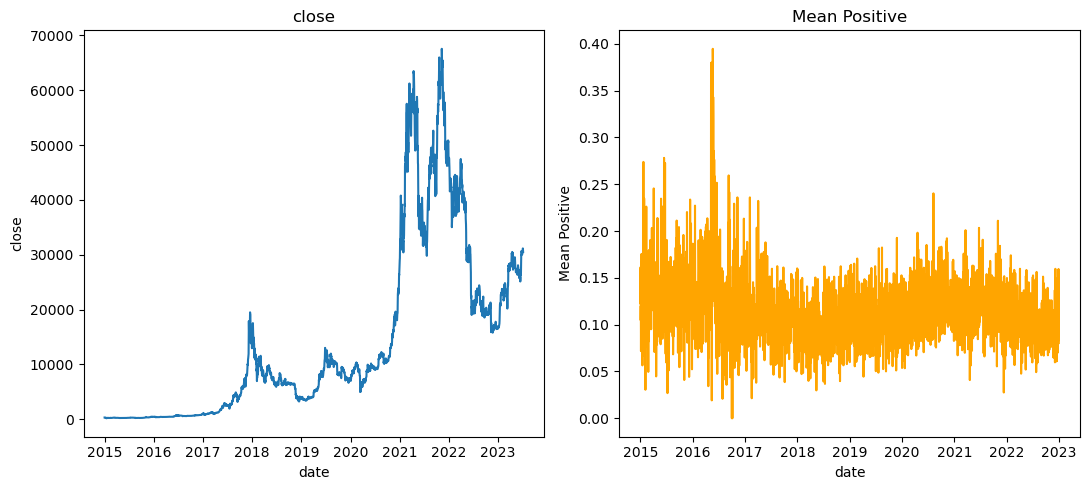

In [57]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_df,
    'close',
    'pos_avg',
    custom_b_name="Mean Positive"
)

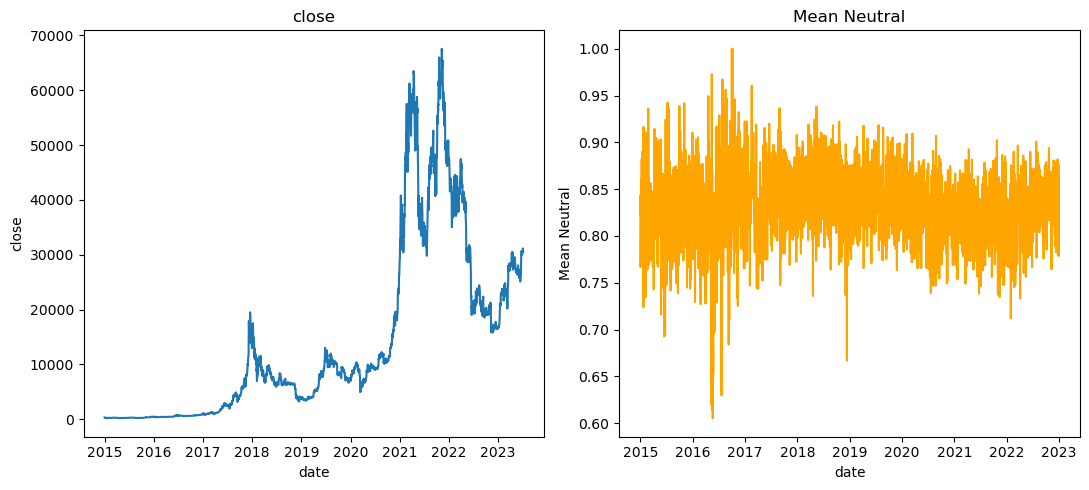

In [58]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_df,
    'close',
    'neu_avg',
    custom_b_name="Mean Neutral"
)

In [59]:
bitcoin_average_sentiments_min_max = bitcoin_average_sentiments_df
bitcoin_average_sentiments_min_max["pos_avg"] = apply_min_max(bitcoin_average_sentiments_min_max["pos_avg"])
bitcoin_average_sentiments_min_max["neg_avg"] = apply_min_max(bitcoin_average_sentiments_min_max["neg_avg"])
bitcoin_average_sentiments_min_max["neu_avg"] = apply_min_max(bitcoin_average_sentiments_min_max["neu_avg"])
bitcoin_average_sentiments_min_max["compound_avg"] = apply_min_max(bitcoin_average_sentiments_min_max["compound_avg"])

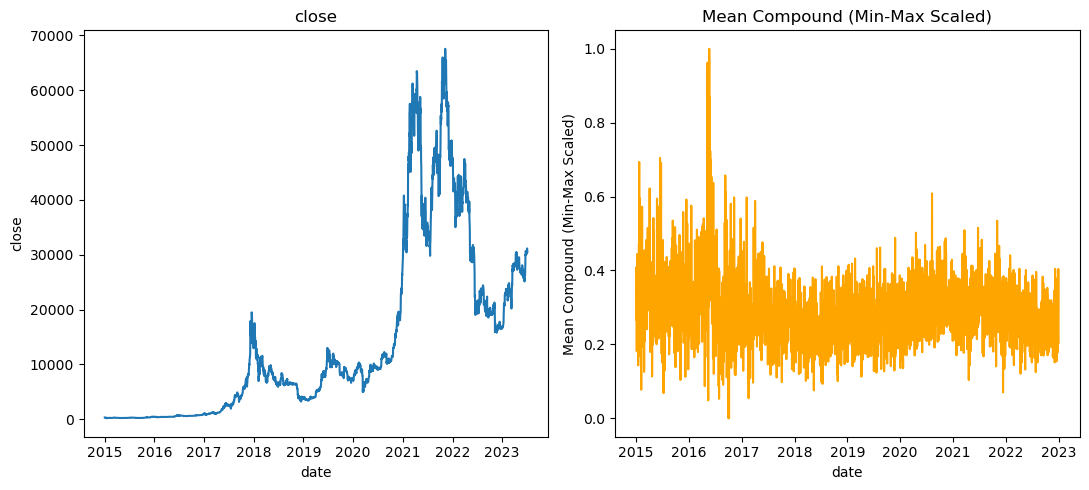

In [60]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_min_max,
    'close',
    'pos_avg',
    custom_b_name="Mean Compound (Min-Max Scaled)"
)

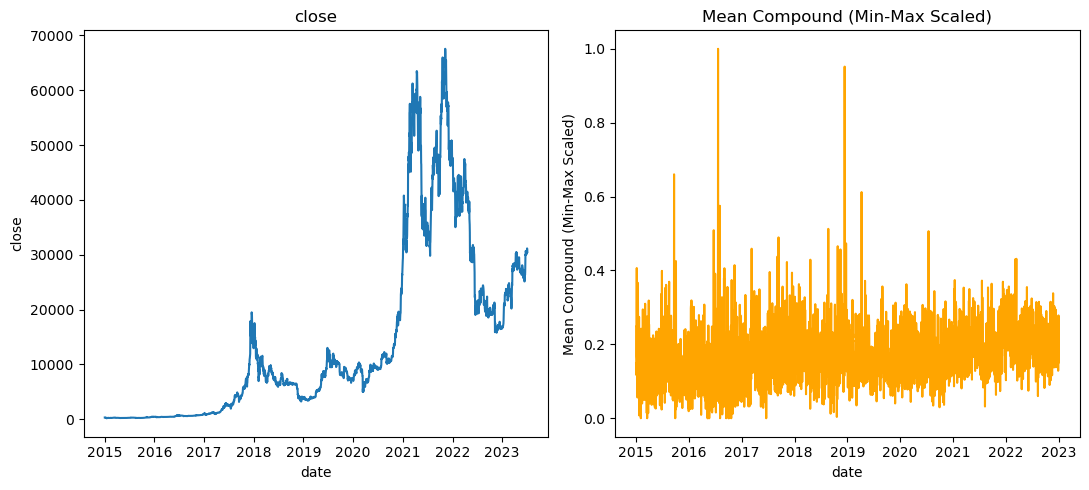

In [61]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_min_max,
    'close',
    'neg_avg',
    custom_b_name="Mean Compound (Min-Max Scaled)"
)

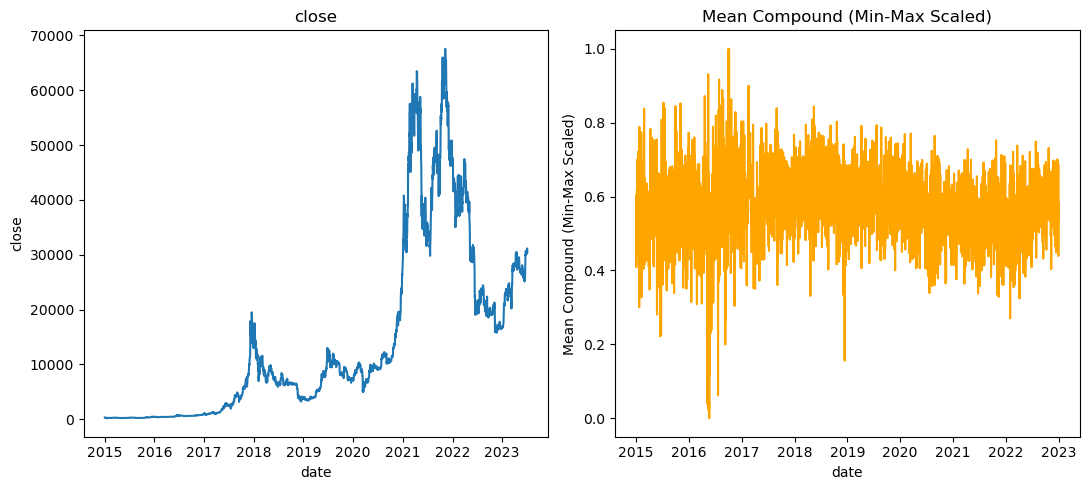

In [62]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_min_max,
    'close',
    'neu_avg',
    custom_b_name="Mean Compound (Min-Max Scaled)"
)

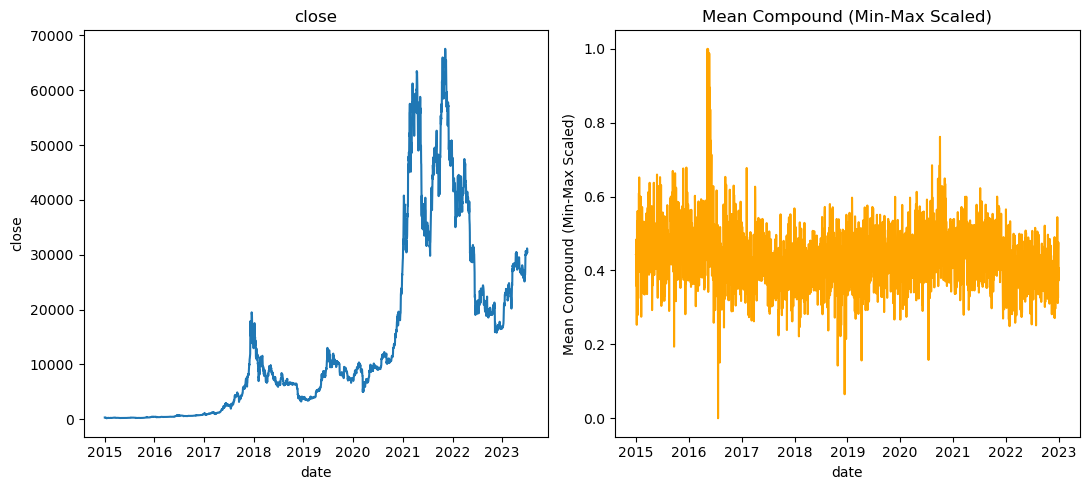

In [63]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_min_max,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Min-Max Scaled)"
)

In [64]:
bitcoin_average_sentiments_std = bitcoin_average_sentiments_df
bitcoin_average_sentiments_std["pos_avg"] = apply_standarization(bitcoin_average_sentiments_std["pos_avg"])
bitcoin_average_sentiments_std["neg_avg"] = apply_standarization(bitcoin_average_sentiments_std["neg_avg"])
bitcoin_average_sentiments_std["neu_avg"] = apply_standarization(bitcoin_average_sentiments_std["neu_avg"])
bitcoin_average_sentiments_std["compound_avg"] = apply_standarization(bitcoin_average_sentiments_std["compound_avg"])

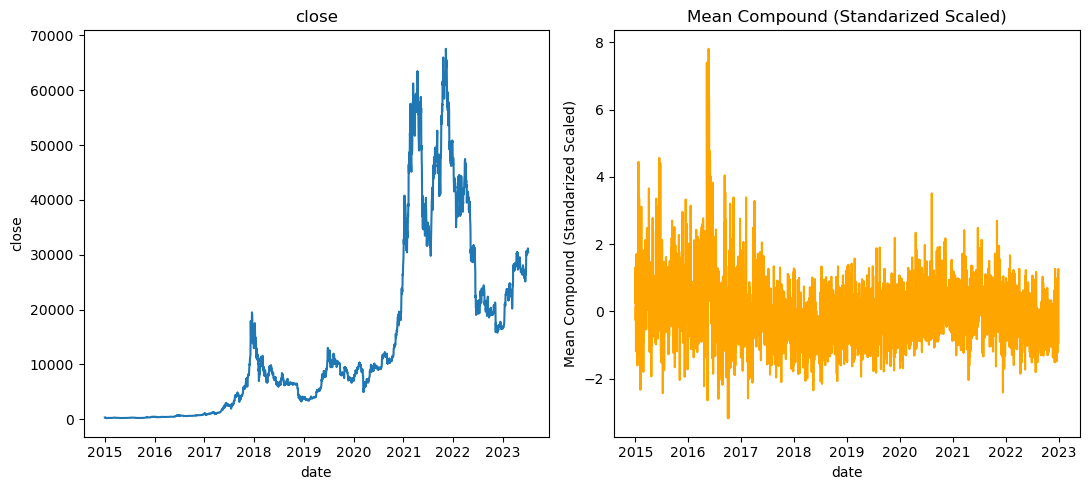

In [65]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std,
    'close',
    'pos_avg',
    custom_b_name="Mean Compound (Standarized Scaled)"
)

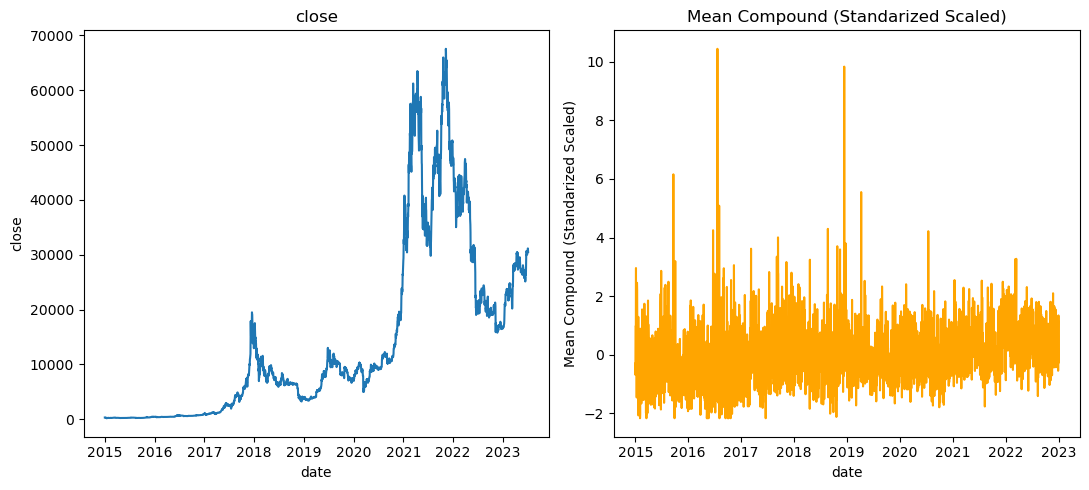

In [66]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std,
    'close',
    'neg_avg',
    custom_b_name="Mean Compound (Standarized Scaled)"
)

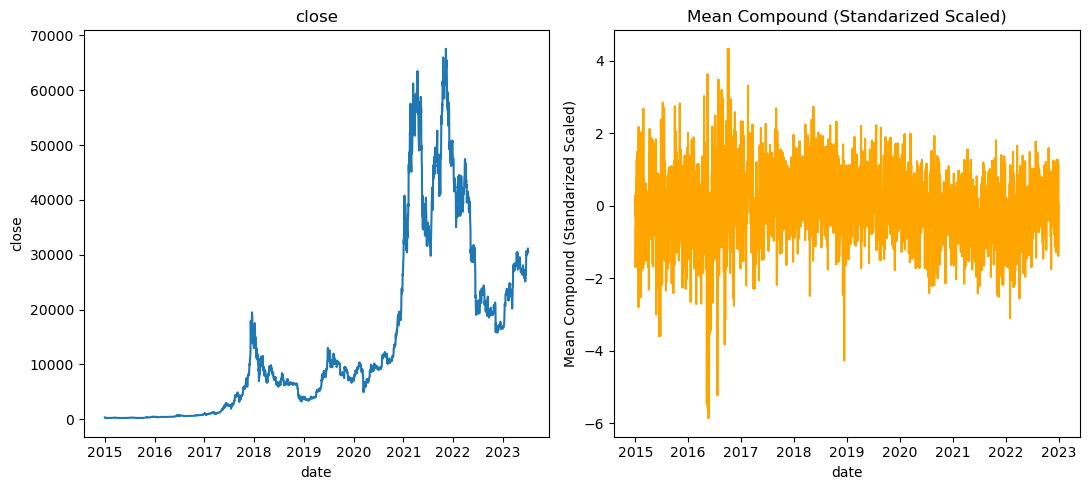

In [67]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std,
    'close',
    'neu_avg',
    custom_b_name="Mean Compound (Standarized Scaled)"
)

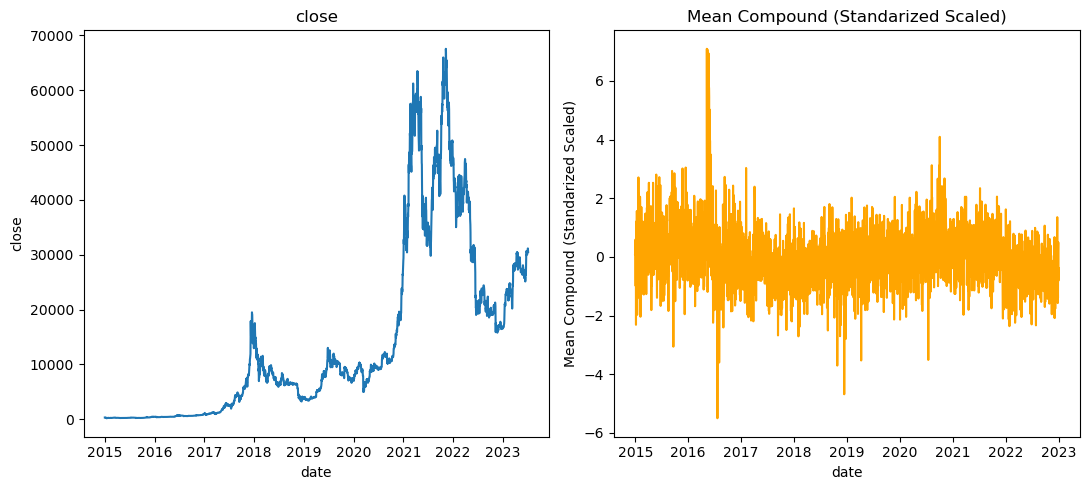

In [68]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Standarized Scaled)"
)

In [69]:
bitcoin_average_sentiments_minmax_sma = bitcoin_average_sentiments_df
bitcoin_average_sentiments_minmax_sma["compound_avg"] = sma(apply_min_max(bitcoin_average_sentiments_minmax_sma["compound_avg"]), 30)
bitcoin_average_sentiments_minmax_sma["pos_avg"] = sma(apply_min_max(bitcoin_average_sentiments_minmax_sma["pos_avg"]), 30)
bitcoin_average_sentiments_minmax_sma["neg_avg"] = sma(apply_min_max(bitcoin_average_sentiments_minmax_sma["neg_avg"]), 30)
bitcoin_average_sentiments_minmax_sma["neu_avg"] = sma(apply_min_max(bitcoin_average_sentiments_minmax_sma["neu_avg"]), 30)

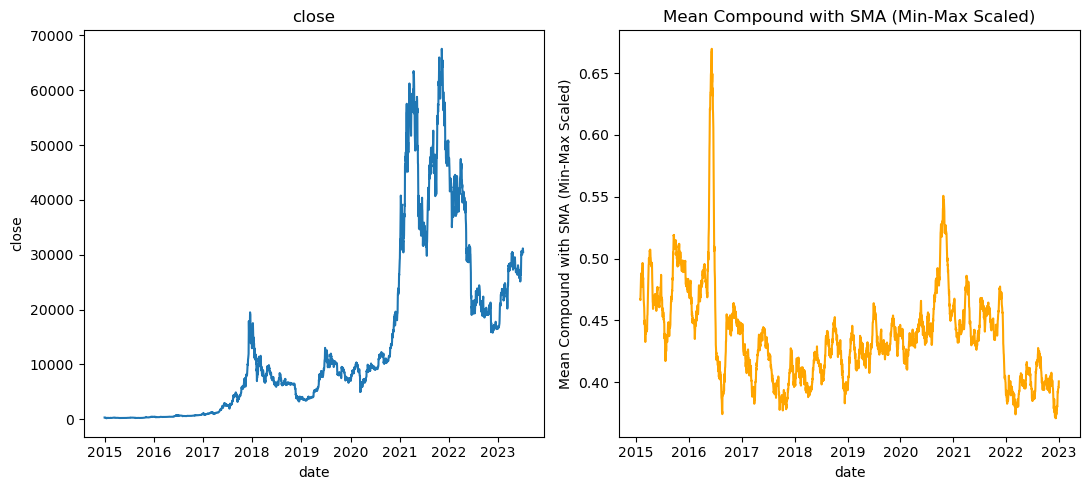

In [70]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_minmax_sma,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound with SMA (Min-Max Scaled)"
)

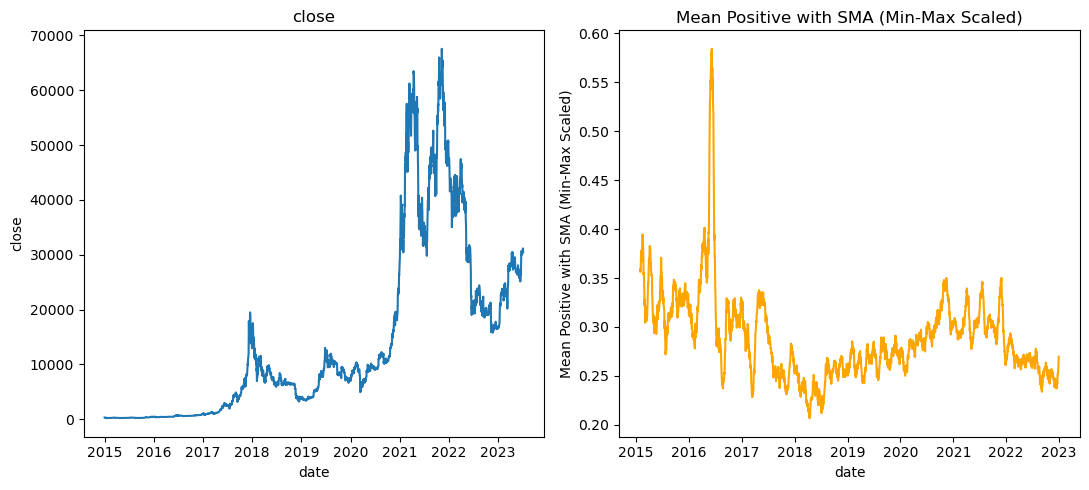

In [71]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_minmax_sma,
    'close',
    'pos_avg',
    custom_b_name="Mean Positive with SMA (Min-Max Scaled)"
)

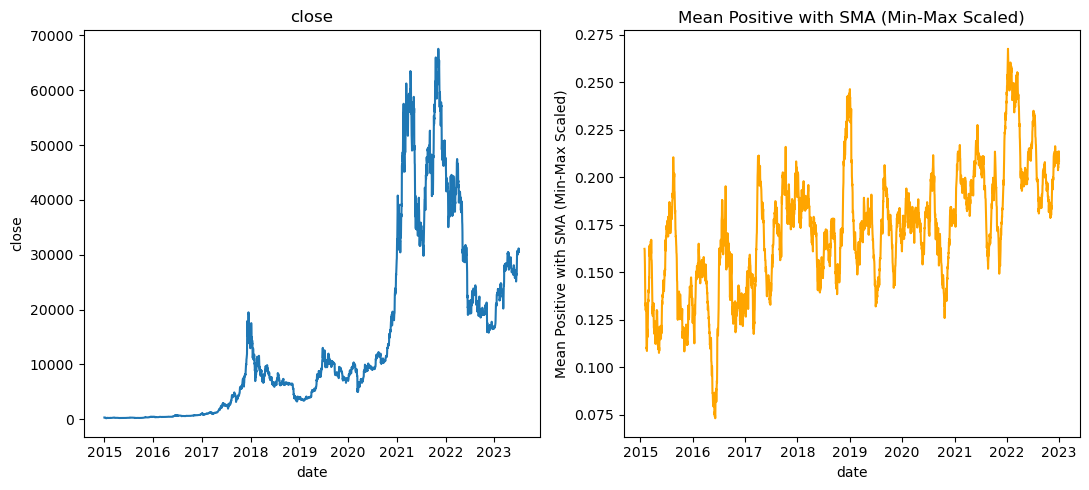

In [72]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_minmax_sma,
    'close',
    'neg_avg',
    custom_b_name="Mean Positive with SMA (Min-Max Scaled)"
)

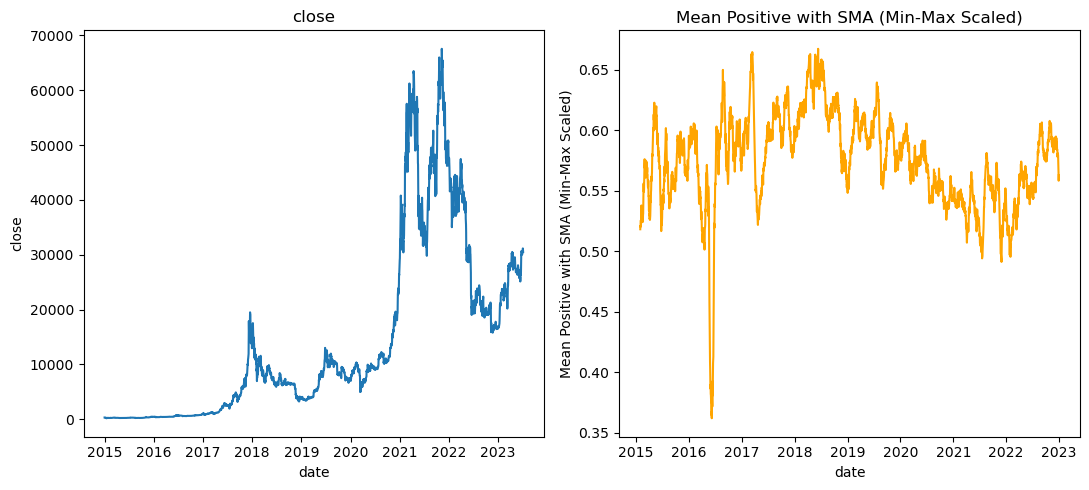

In [73]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_minmax_sma,
    'close',
    'neu_avg',
    custom_b_name="Mean Positive with SMA (Min-Max Scaled)"
)

In [74]:
bitcoin_average_sentiments_std_sma = bitcoin_average_sentiments_df
bitcoin_average_sentiments_std_sma["compound_avg"] = sma(apply_standarization(bitcoin_average_sentiments_std_sma["compound_avg"]), 30)
bitcoin_average_sentiments_std_sma["pos_avg"] = sma(apply_standarization(bitcoin_average_sentiments_std_sma["pos_avg"]), 30)
bitcoin_average_sentiments_std_sma["neg_avg"] = sma(apply_standarization(bitcoin_average_sentiments_std_sma["neg_avg"]), 30)
bitcoin_average_sentiments_std_sma["neu_avg"] = sma(apply_standarization(bitcoin_average_sentiments_std_sma["neu_avg"]), 30)

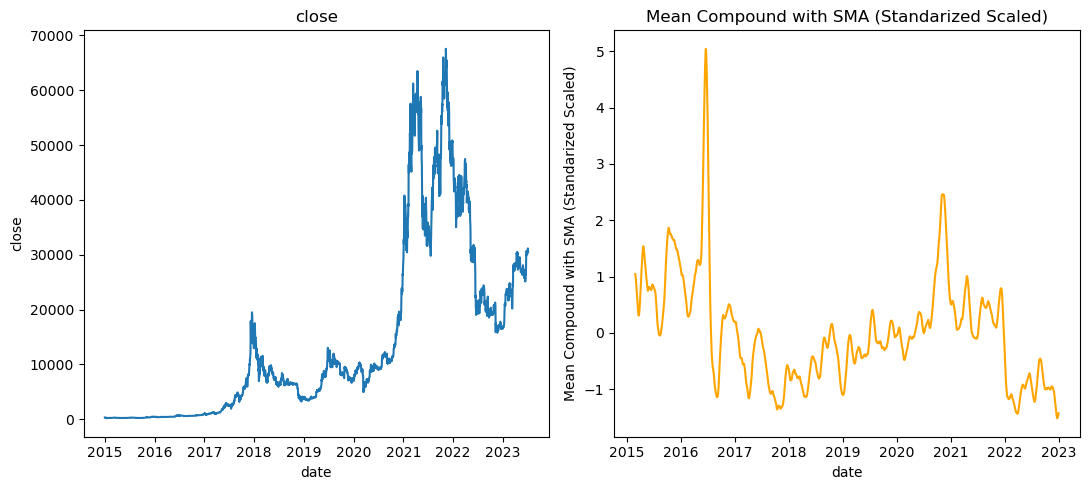

In [75]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std_sma,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound with SMA (Standarized Scaled)"
)

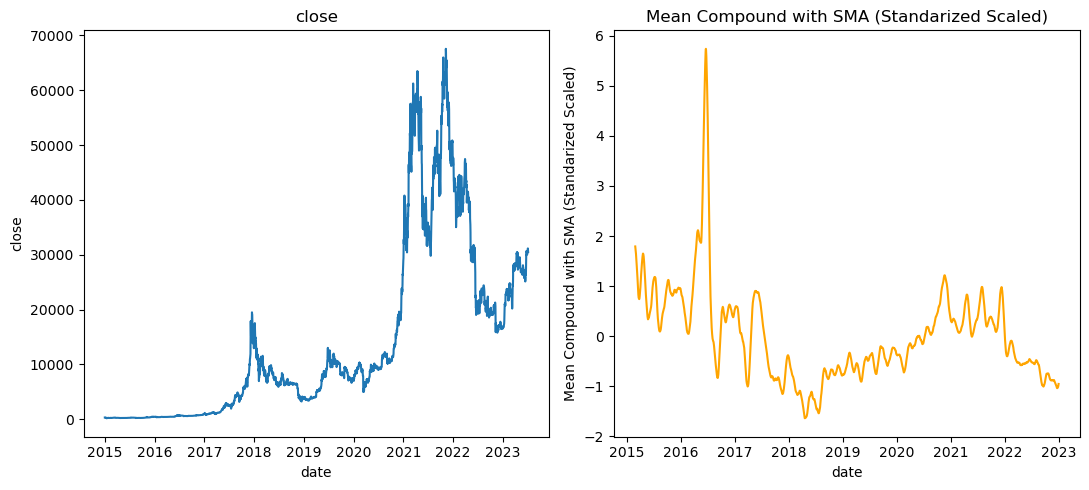

In [76]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std_sma,
    'close',
    'pos_avg',
    custom_b_name="Mean Compound with SMA (Standarized Scaled)"
)

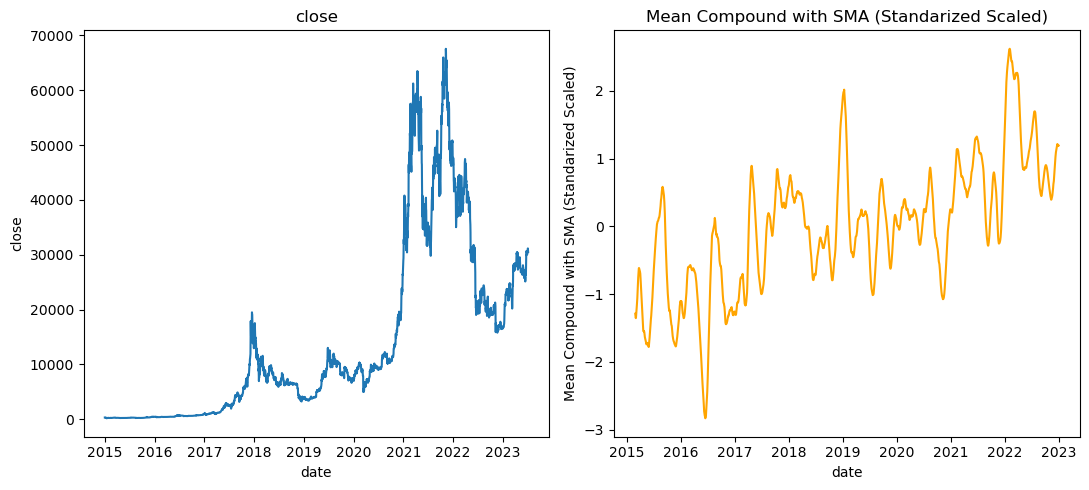

In [77]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std_sma,
    'close',
    'neg_avg',
    custom_b_name="Mean Compound with SMA (Standarized Scaled)"
)

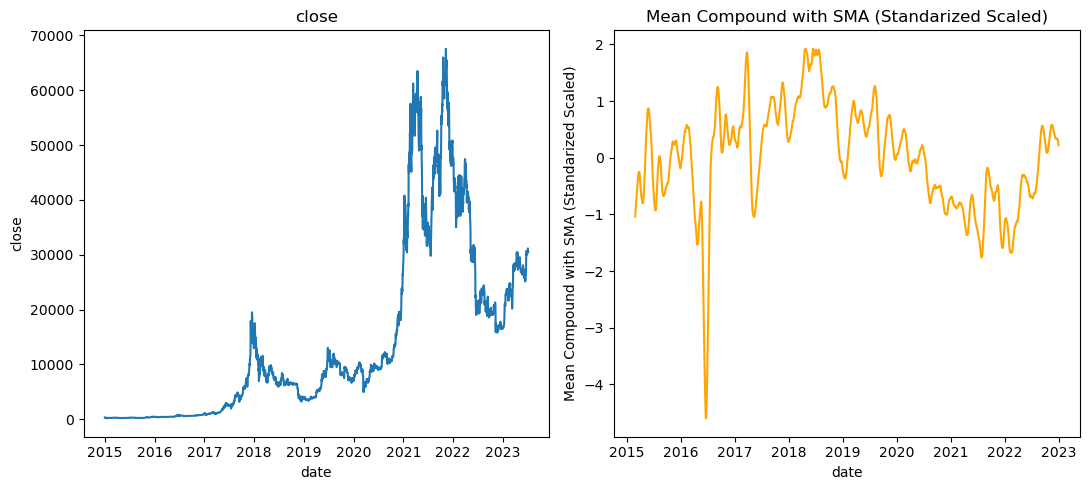

In [78]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std_sma,
    'close',
    'neu_avg',
    custom_b_name="Mean Compound with SMA (Standarized Scaled)"
)

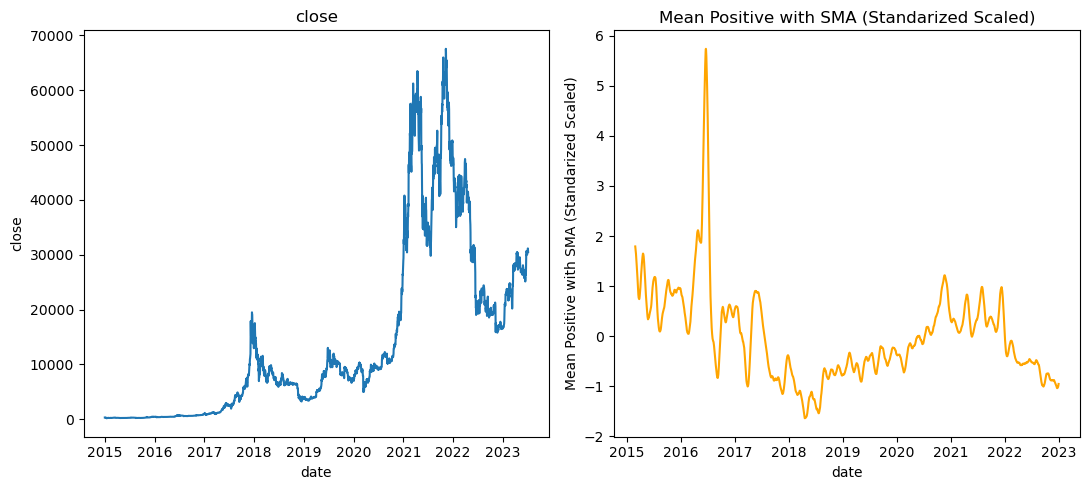

In [79]:
print_plots(
    bitcoin_df,
    bitcoin_average_sentiments_std_sma,
    'close',
    'pos_avg',
    custom_b_name="Mean Positive with SMA (Standarized Scaled)"
)

In [80]:
bitcoin_all_sentiments = pd.DataFrame(data=transformed_bitcoin_tweet_list)

In [81]:
bitcoin_all_sentiments_min_max = bitcoin_all_sentiments
bitcoin_all_sentiments_min_max["compound"] = apply_min_max(bitcoin_all_sentiments_min_max["compound"])
bitcoin_all_sentiments_min_max_dict = bitcoin_all_sentiments_min_max.to_dict(orient='records')
bitcoin_all_sentiments_min_max_dict_average = list(merge_and_accumulate(bitcoin_all_sentiments_min_max_dict))
bitcoin_all_sentiments_min_max_dict_average_df = pd.DataFrame(data=bitcoin_all_sentiments_min_max_dict_average)

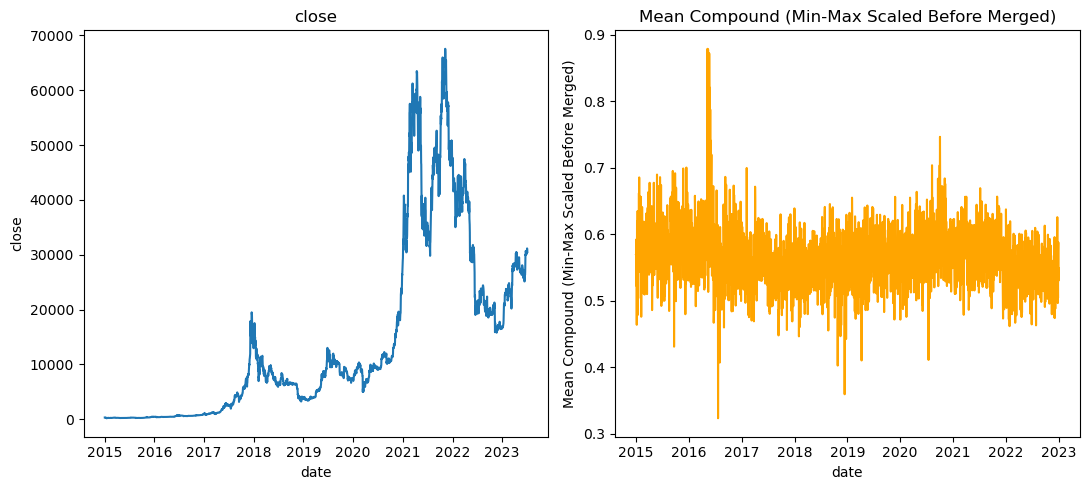

In [82]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_min_max_dict_average_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Min-Max Scaled Before Merged)"
)

In [83]:
bitcoin_all_sentiments_std = bitcoin_all_sentiments
bitcoin_all_sentiments_std["compound"] = apply_standarization(bitcoin_all_sentiments_std["compound"])
bitcoin_all_sentiments_std_dict = bitcoin_all_sentiments_std.to_dict(orient='records')
bitcoin_all_sentiments_std_dict_average = list(merge_and_accumulate(bitcoin_all_sentiments_std_dict))
bitcoin_all_sentiments_std_dict_average_df = pd.DataFrame(data=bitcoin_all_sentiments_std_dict_average)

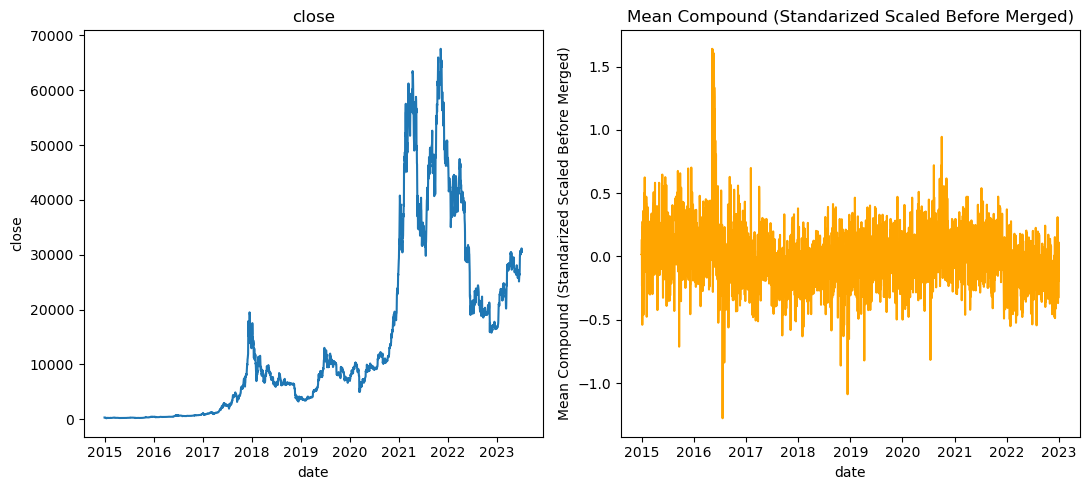

In [84]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_std_dict_average_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Standarized Scaled Before Merged)"
)

In [85]:
bitcoin_all_sentiments_min_max_dict_average_sma_df = pd.DataFrame(bitcoin_all_sentiments_min_max_dict_average)
bitcoin_all_sentiments_min_max_dict_average_sma_df["compound_avg"] = sma(bitcoin_all_sentiments_min_max_dict_average_sma_df["compound_avg"], 30)
bitcoin_all_sentiments_min_max_dict_average_sma_df["pos_avg"] = sma(bitcoin_all_sentiments_min_max_dict_average_sma_df["pos_avg"], 30)
bitcoin_all_sentiments_min_max_dict_average_sma_df["neg_avg"] = sma(bitcoin_all_sentiments_min_max_dict_average_sma_df["neg_avg"], 30)
bitcoin_all_sentiments_min_max_dict_average_sma_df["neu_avg"] = sma(bitcoin_all_sentiments_min_max_dict_average_sma_df["neu_avg"], 30)

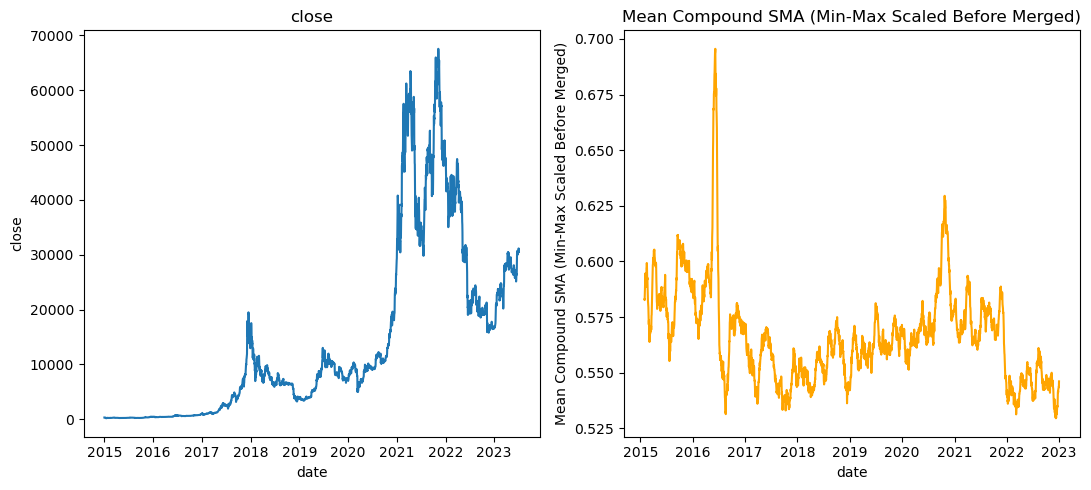

In [86]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_min_max_dict_average_sma_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound SMA (Min-Max Scaled Before Merged)"
)

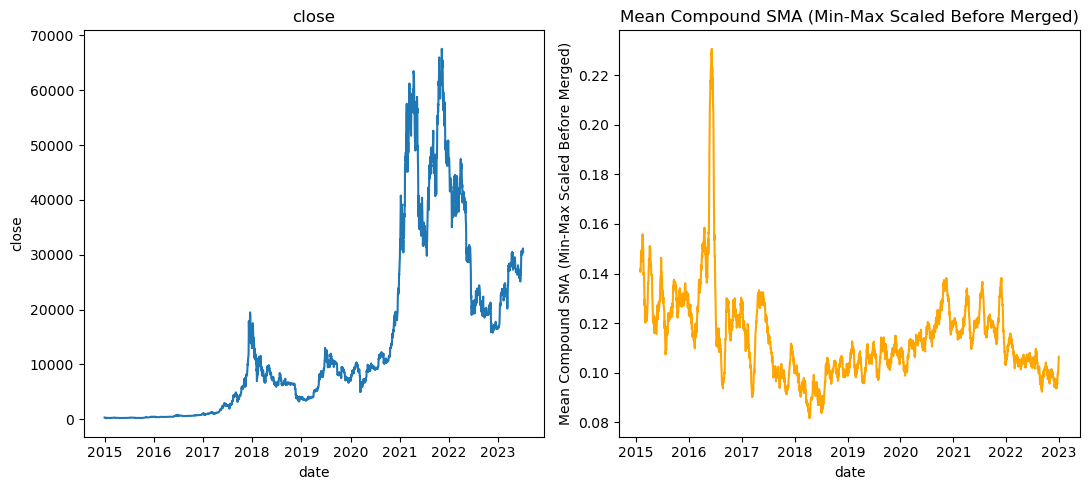

In [87]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_min_max_dict_average_sma_df,
    'close',
    'pos_avg',
    custom_b_name="Mean Compound SMA (Min-Max Scaled Before Merged)"
)

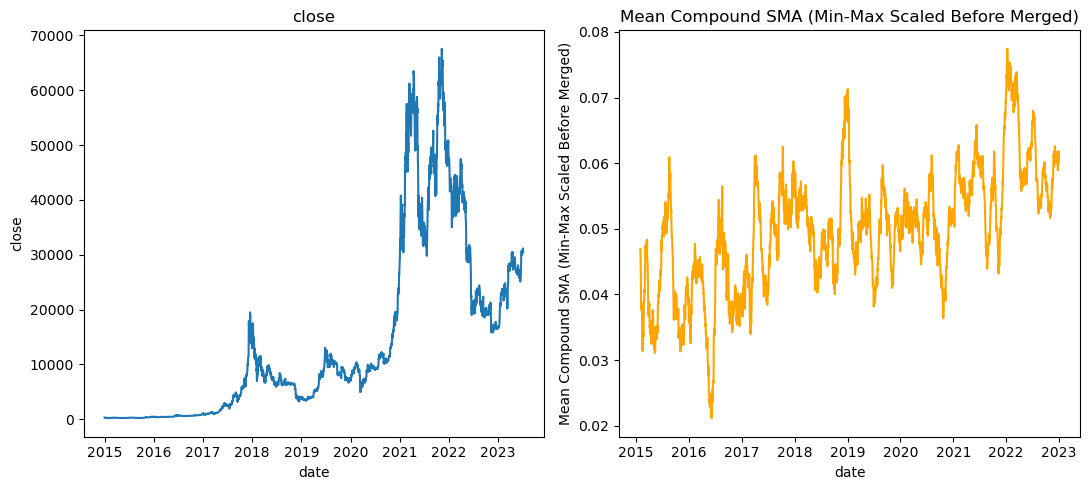

In [88]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_min_max_dict_average_sma_df,
    'close',
    'neg_avg',
    custom_b_name="Mean Compound SMA (Min-Max Scaled Before Merged)"
)

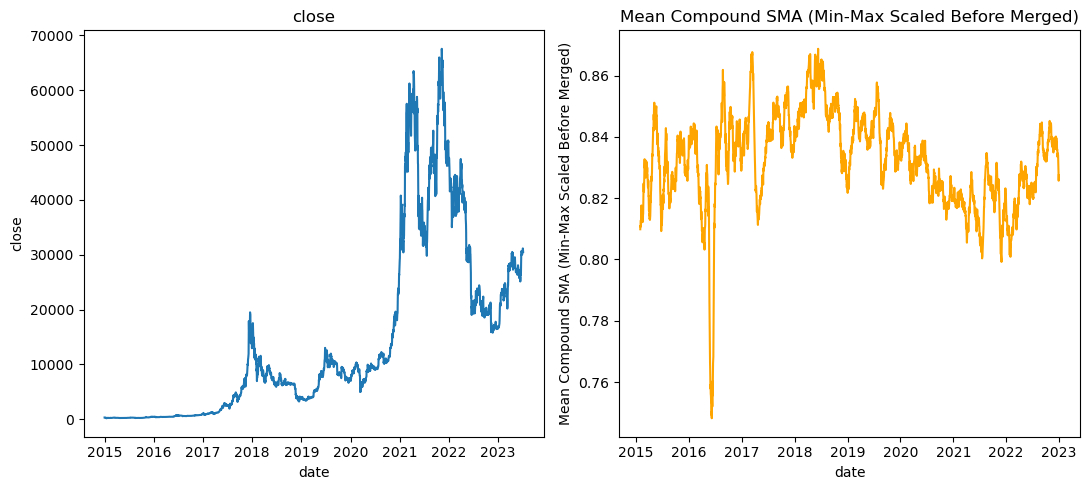

In [89]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_min_max_dict_average_sma_df,
    'close',
    'neu_avg',
    custom_b_name="Mean Compound SMA (Min-Max Scaled Before Merged)"
)

In [90]:
bitcoin_all_sentiments_std_dict_average_sma_df = pd.DataFrame(bitcoin_all_sentiments_std_dict_average)
bitcoin_all_sentiments_std_dict_average_sma_df["compound_avg"] = sma(bitcoin_all_sentiments_std_dict_average_sma_df["compound_avg"], 30)
bitcoin_all_sentiments_std_dict_average_sma_df["pos_avg"] = sma(bitcoin_all_sentiments_std_dict_average_sma_df["pos_avg"], 30)
bitcoin_all_sentiments_std_dict_average_sma_df["neg_avg"] = sma(bitcoin_all_sentiments_std_dict_average_sma_df["neg_avg"], 30)
bitcoin_all_sentiments_std_dict_average_sma_df["neu_avg"] = sma(bitcoin_all_sentiments_std_dict_average_sma_df["neu_avg"], 30)

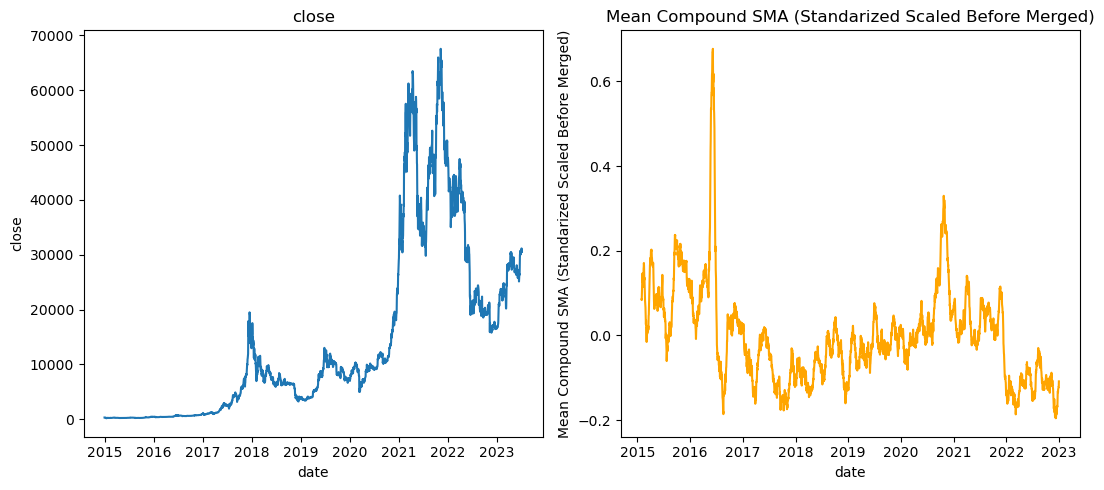

In [91]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_std_dict_average_sma_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound SMA (Standarized Scaled Before Merged)"
)

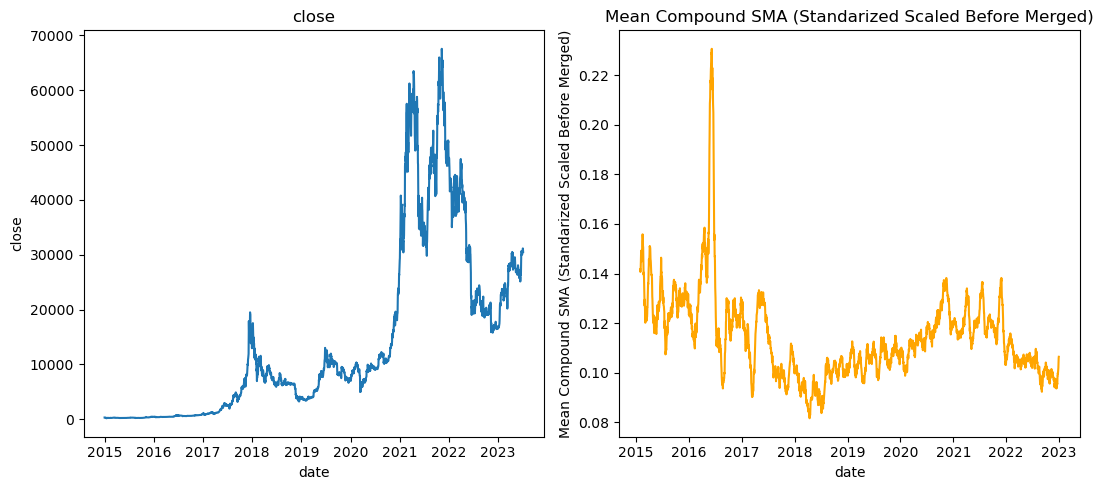

In [92]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_std_dict_average_sma_df,
    'close',
    'pos_avg',
    custom_b_name="Mean Compound SMA (Standarized Scaled Before Merged)"
)

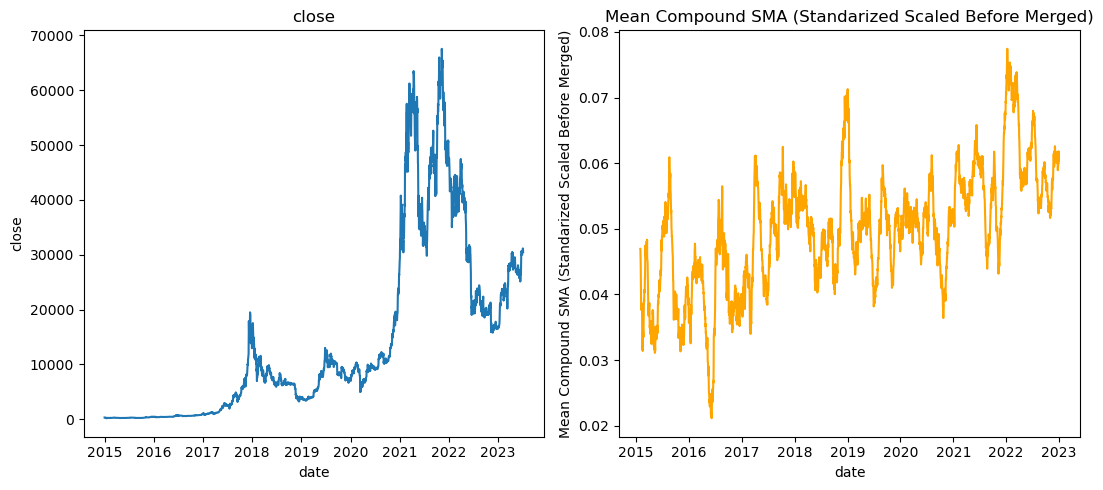

In [93]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_std_dict_average_sma_df,
    'close',
    'neg_avg',
    custom_b_name="Mean Compound SMA (Standarized Scaled Before Merged)"
)

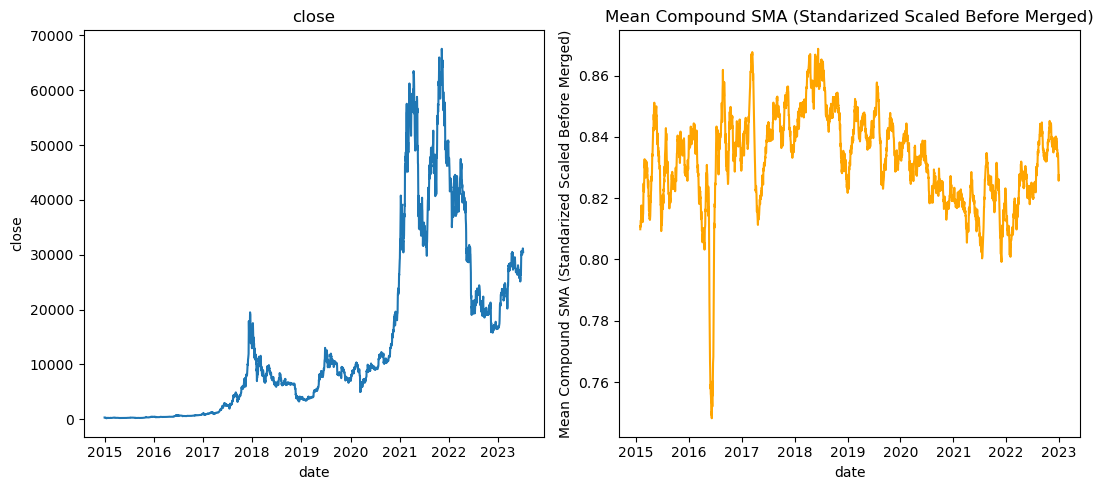

In [94]:
print_plots(
    bitcoin_df,
    bitcoin_all_sentiments_std_dict_average_sma_df,
    'close',
    'neu_avg',
    custom_b_name="Mean Compound SMA (Standarized Scaled Before Merged)"
)

In [95]:
#Compare Scale Before And After Merge

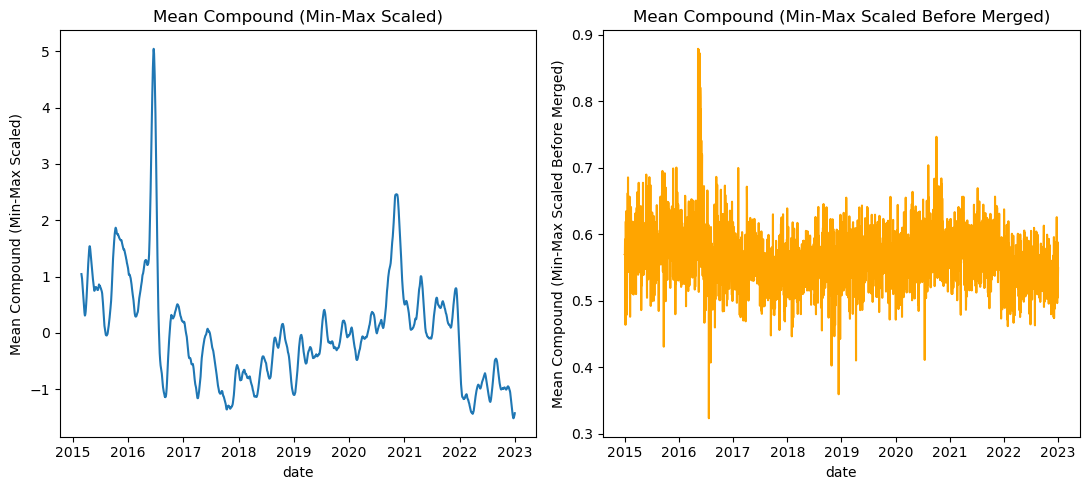

In [96]:
print_plots(
    bitcoin_average_sentiments_min_max,
    bitcoin_all_sentiments_min_max_dict_average_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound (Min-Max Scaled)",
    custom_b_name="Mean Compound (Min-Max Scaled Before Merged)"
)

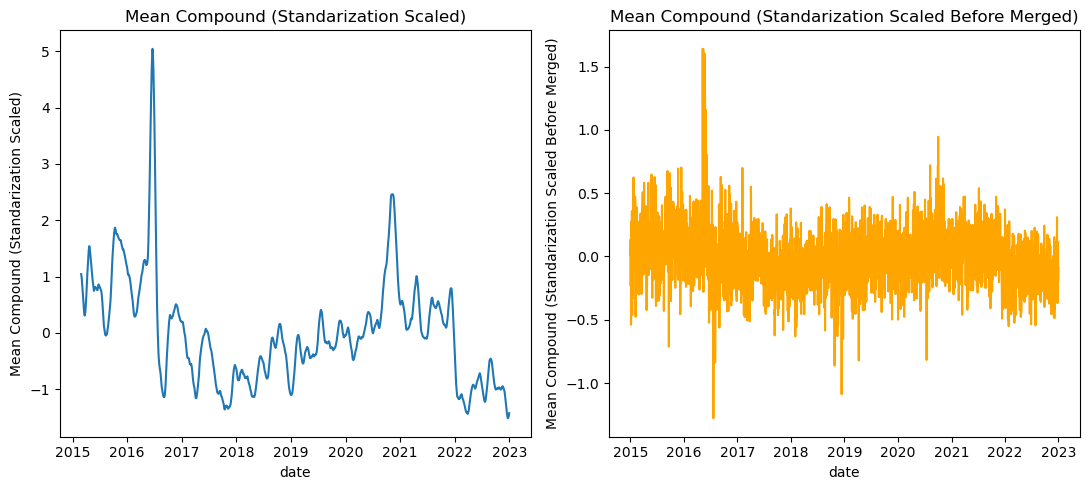

In [97]:
print_plots(
    bitcoin_average_sentiments_std,
    bitcoin_all_sentiments_std_dict_average_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound (Standarization Scaled)",
    custom_b_name="Mean Compound (Standarization Scaled Before Merged)"
)

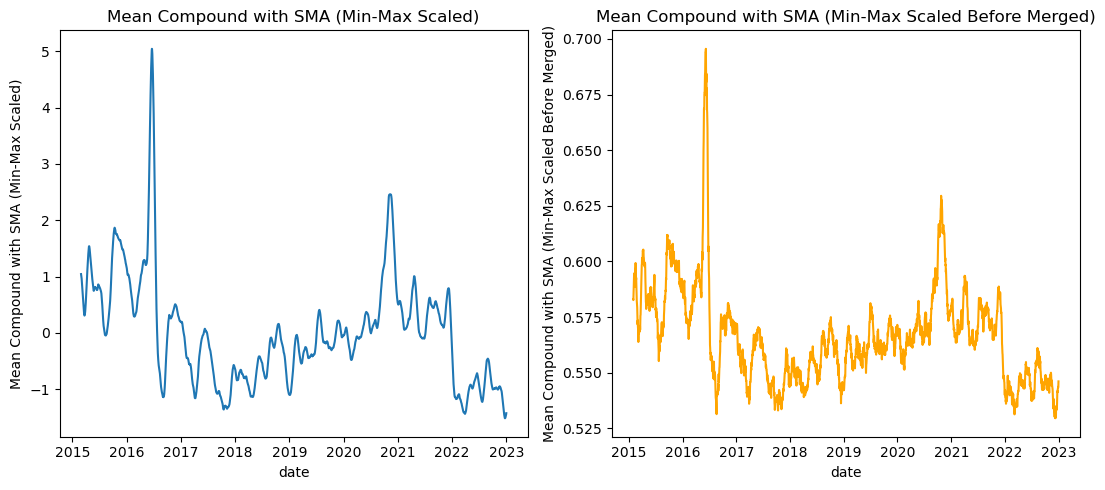

In [98]:
print_plots(
    bitcoin_average_sentiments_minmax_sma,
    bitcoin_all_sentiments_min_max_dict_average_sma_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound with SMA (Min-Max Scaled)",
    custom_b_name="Mean Compound with SMA (Min-Max Scaled Before Merged)"
)

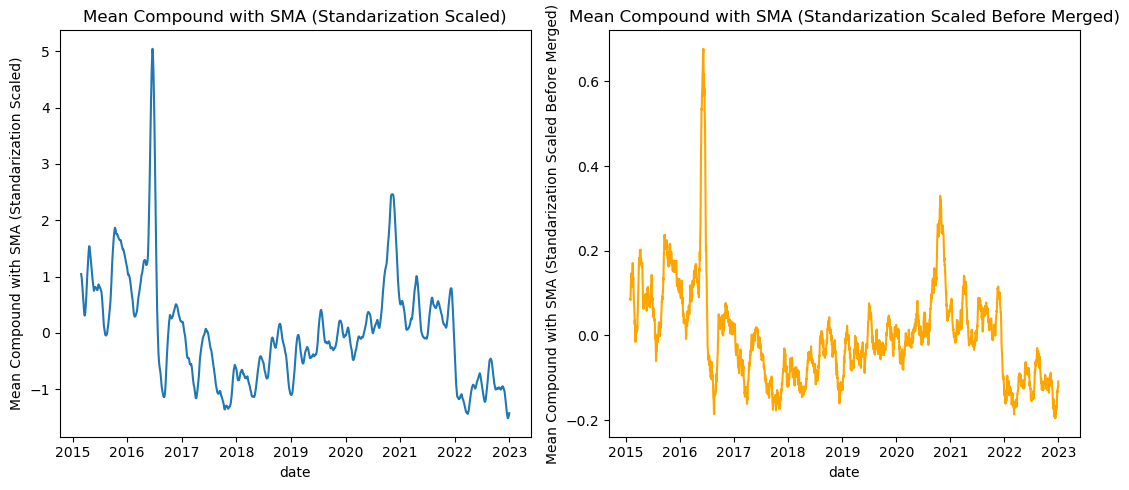

In [99]:
print_plots(
    bitcoin_average_sentiments_std_sma,
    bitcoin_all_sentiments_std_dict_average_sma_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound with SMA (Standarization Scaled)",
    custom_b_name="Mean Compound with SMA (Standarization Scaled Before Merged)"
)

In [100]:
def choose_other(field_str, trend):
    if trend == "higher":
        return f"{field_str}_lower"
    elif trend == "lower":
        return f"{field_str}_higher"

In [101]:
def create_trends(field_str):
    prev = None
    trend = None
    def map_obj(obj):
        nonlocal prev
        nonlocal trend
        if np.isnan(obj[field_str]):
            if trend == None:
                obj[f"{field_str}_lower"] = 0
                obj[f"{field_str}_higher"] = 0
            else:
                obj[f"{field_str}_{trend}"] = 1
                obj[choose_other(field_str, trend)] = 0
        else:
            if prev == None:
                obj[f"{field_str}_lower"] = 0
                obj[f"{field_str}_higher"] = 0
            else:
                if obj[field_str] < prev:
                    obj[f"{field_str}_lower"] = 1
                    obj[f"{field_str}_higher"] = 0
                    trend = "lower"
                else:
                    obj[f"{field_str}_lower"] = 0
                    obj[f"{field_str}_higher"] = 1
                    trend = "higher"
            prev = obj[field_str]
        return obj
    return map_obj

In [102]:
def merge_two_df_by_dates(df1, df2):
    df1['date'] = pd.to_datetime(df1['date'])
    df2['date'] = pd.to_datetime(df2['date'])
    df1['date'] = df1['date'].dt.tz_localize(None)
    df2['date'] = df2['date'].dt.tz_localize(None)
    merged_df = pd.merge(df1, df2, on='date', how='right')
    return merged_df

In [103]:
average_sentiments_min_max = average_sentiments_df
average_sentiments_min_max["compound_avg"] = apply_min_max(average_sentiments_min_max["compound_avg"])

In [104]:
#Investing Sentiments SMA Min-Max-Scaled
mapped_sentiments_array = average_sentiments_minmax_sma.apply(create_trends("compound_avg"), axis=1)

In [105]:
#Amazon Close Markets SMA Min-Max-Scaled
marketd = pd.DataFrame(list(prices.find({"market": ObjectId("6511914e0ef18f573bbaaef7"), "date": { "$gte": "2015-01-01", "$lte": "2021-01-01"}})))
marketd["close"] = sma(apply_min_max(marketd["close"]), 30)

In [106]:
df = merge_two_df_by_dates(marketd, mapped_sentiments_array)

In [107]:
df = df.apply(create_trends("close"), axis=1)

In [108]:
df = df.apply(create_trends("volume"), axis=1)

In [109]:
df = df[["date", "close_higher", "close_lower", "volume_higher", "volume_lower", "compound_avg_higher", "compound_avg_lower"]]

In [110]:
# Economic Indicators
cpis = pd.DataFrame(data=list(economic_indicators.find({ "type": "CPI", "date": { "$gte": "2015-01-01", "$lte": "2021-01-01" }})))
dgo = pd.DataFrame(data=list(economic_indicators.find({ "type": "DurableGoodsOrders", "date": { "$gte": "2015-01-01", "$lte": "2021-01-01" }})))
ffr = pd.DataFrame(data=list(economic_indicators.find({ "type": "FederalFundsRate", "date": { "$gte": "2015-01-01", "$lte": "2021-01-01" }})))
nnp = pd.DataFrame(data=list(economic_indicators.find({ "type": "NonfarmPayroll", "date": { "$gte": "2015-01-01", "$lte": "2021-01-01" }})))
rets = pd.DataFrame(data=list(economic_indicators.find({ "type": "RetailSales", "date": { "$gte": "2015-01-01", "$lte": "2021-01-01" }})))
tryi = pd.DataFrame(data=list(economic_indicators.find({ "type": "TreasuryYield", "date": { "$gte": "2015-01-01", "$lte": "2021-01-01" }})))
unem = pd.DataFrame(data=list(economic_indicators.find({ "type": "UnemploymentRate", "date": { "$gte": "2015-01-01", "$lte": "2021-01-01" }})))

In [111]:
df = merge_two_df_by_dates(cpis.iloc[::-1].reset_index(drop=True), df)
df = df.drop(['_id', 'type'], axis=1).apply(create_trends("value"), axis=1).rename(columns={"value": "cpi_value", "value_lower": "cpi_lower", "value_higher": "cpi_higher"}).drop('cpi_value', axis=1)

In [112]:
df = merge_two_df_by_dates(dgo.iloc[::-1].reset_index(drop=True), df)
df = df.drop(['_id', 'type'], axis=1).apply(create_trends("value"), axis=1).rename(columns={"value": "dgo_value", "value_lower": "dgo_lower", "value_higher": "dgo_higher"}).drop('dgo_value', axis=1)

In [113]:
df = merge_two_df_by_dates(ffr.iloc[::-1].reset_index(drop=True), df)
df = df.drop(['_id', 'type'], axis=1).apply(create_trends("value"), axis=1).rename(columns={"value": "ffr_value", "value_lower": "ffr_lower", "value_higher": "ffr_higher"}).drop('ffr_value', axis=1)

In [114]:
df = merge_two_df_by_dates(nnp.iloc[::-1].reset_index(drop=True), df)
df = df.drop(['_id', 'type'], axis=1).apply(create_trends("value"), axis=1).rename(columns={"value": "nnp_value", "value_lower": "nnp_lower", "value_higher": "nnp_higher"}).drop('nnp_value', axis=1)

In [115]:
df = merge_two_df_by_dates(rets.iloc[::-1].reset_index(drop=True), df)
df = df.drop(['_id', 'type'], axis=1).apply(create_trends("value"), axis=1).rename(columns={"value": "rets_value", "value_lower": "rets_lower", "value_higher": "rets_higher"}).drop('rets_value', axis=1)

In [116]:
df = merge_two_df_by_dates(tryi.iloc[::-1].reset_index(drop=True), df)
df = df.drop(['_id', 'type'], axis=1).apply(create_trends("value"), axis=1).rename(columns={"value": "try_value", "value_lower": "try_lower", "value_higher": "try_higher"}).drop('try_value', axis=1)

In [117]:
df = merge_two_df_by_dates(unem.iloc[::-1].reset_index(drop=True), df)
df = df.drop(['_id', 'type'], axis=1).apply(create_trends("value"), axis=1).rename(columns={"value": "une_value", "value_lower": "une_lower", "value_higher": "une_higher"}).drop('une_value', axis=1)

In [118]:
pd.set_option('display.max_rows', None)  # to display all rows
pd.set_option('display.max_columns', None)  # to display all columns

In [119]:
df[[
    'close_higher', 'close_lower', 'compound_avg_higher', 'compound_avg_lower', 
    'cpi_higher', 'cpi_lower', 'dgo_higher', 'dgo_lower', 
    'ffr_higher', 'ffr_lower', 'nnp_higher', 'nnp_lower', 'rets_higher', 
    'rets_lower', 'try_higher', 'try_lower', 'une_higher', 'une_lower', 
    'volume_higher', 'volume_lower'
]]

,close_higher,close_lower,compound_avg_higher,compound_avg_lower,cpi_higher,cpi_lower,dgo_higher,dgo_lower,ffr_higher,ffr_lower,nnp_higher,nnp_lower,rets_higher,rets_lower,try_higher,try_lower,une_higher,une_lower,volume_higher,volume_lower
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
6,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
7,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0
8,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
9,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1


In [120]:
from Apriori import apriori

In [126]:
result = apriori(tx=df, min_support=0.0005, max_length=2, min_confidence=0.0025, min_lift=1.01)

Elapsed time: 0.6406586170196533 seconds


In [149]:
resultsinDataFrame = pd.DataFrame(result, columns = ['lhs', 'rhs', 'support', 'confidence', 'lift'])
filtered_df = resultsinDataFrame[resultsinDataFrame['lhs'].apply(lambda x: 'compound_avg_higher' in x or 'close_higher' in x or 'compound_avg_lower' in x or 'close_lower' in x)] 
filtered_df

,lhs,rhs,support,confidence,lift
4,(close_lower),(cpi_lower),0.103102,0.359300,1.429377
10,(compound_avg_higher),(nnp_lower),0.146898,0.320717,1.262140
19,(close_lower),(une_higher),0.177920,0.620032,1.238933
21,(close_lower),(ffr_lower),0.021898,0.076312,1.220986
24,(close_lower),(rets_higher),0.176551,0.615262,1.152697
36,(close_lower),(compound_avg_lower),0.166515,0.580286,1.126649
37,(compound_avg_lower),(close_lower),0.166515,0.323295,1.126649
38,(compound_avg_higher),(rets_higher),0.274179,0.598606,1.121490
55,(close_higher),(une_lower),0.369069,0.533641,1.099381
57,(compound_avg_lower),(rets_lower),0.255474,0.496014,1.097137
